# Analysing morphological properties of different celltypes from a xenium experiment

In [46]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
adata = adata[adata.obs['compartment'].str.contains('orsal')]

In [47]:
adata.uns['celltype_assignments_colors'] = [
    '#196eaf',
    '#45a0d6',
    '#68bedd',
    '#c954f4',
    '#178db4',
    '#5fc79c',
    '#e8a020',
    '#f5c85a',
    '#f7dfa0',
    '#b85c3a',
    '#e08a69',
    '#7b3fa0',
    '#c07bd6',
    '#d62728',
    '#ff7f0e',
    '#8c564b',
    '#e377c2',
    '#17becf',
    '#1f77b4',
    '#9467bd',
    '#2ca02c',
    '#98df8a',
    '#bcbd22'
]

## Defining graphing functions

In [2]:
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

def compare_average(celltypes, property, adata):
    data = []
    for celltype in celltypes:
        data.append(adata.obs[adata.obs['celltype_assignments'] == celltype][property].dropna().values)

    # Scale figure width with number of celltypes
    fig, ax = plt.subplots(figsize=(len(celltypes) * 0.8, 6))

    bp = ax.boxplot(data, patch_artist=True, labels=celltypes)

    # Use a colormap that supports arbitrary numbers of colors
    colors = [cm.tab20(i / len(celltypes)) for i in range(len(celltypes))]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_xlabel('Cell Type')
    ax.set_ylabel(property.replace('_', ' ').title())
    ax.set_title(f'Comparison of {property.replace("_", " ").title()} Between Cell Types')

    # Rotate x labels so they don't overlap
    ax.set_xticklabels(celltypes, rotation=45, ha='right')

    legend_handles = [
        mpatches.Patch(color=colors[i], label=celltypes[i])
        for i in range(len(celltypes))
    ]
    ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3492404303.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = data.groupby(group_by)[morph_props].median()


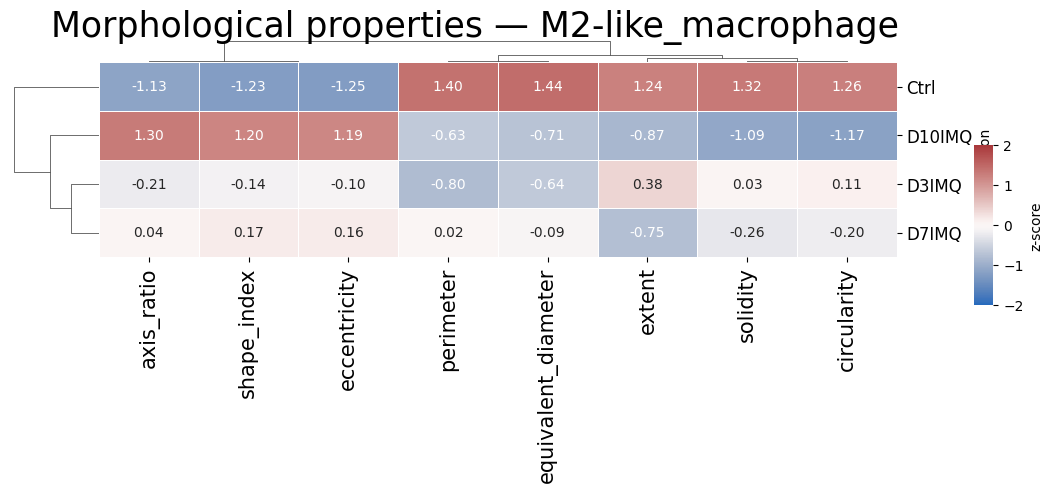

In [53]:
# Cluster map for a given celltype, comparing all properties across samples
#Cluster map of median of features vs sample for a given celltype
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

morph_props = ['shape_index', 'solidity', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter']

def morph_heatmap(adata, celltype, group_by):
    """
    group_by is the sample grouping to use, either condition (course) or batch_key (fine)
    """
    
    data = adata.obs[adata.obs['celltype_assignments'] == celltype]

    # mean per sample per property
    mean_df = data.groupby(group_by)[morph_props].median()

    # min-max normalise each property independently (column-wise)
    norm_df = (mean_df - mean_df.mean()) / mean_df.std()

    g = sns.clustermap(norm_df, cmap='vlag', annot=True, fmt='.2f',
                linewidths=0.5, 
                cbar_kws={'label': 'z-score'},
                dendrogram_ratio=0.1,
                cbar_pos =(1.02, 0.3, 0.02, 0.4),
                figsize = (len(morph_props)*1.2, len(norm_df)*1.0))
    
    g.ax_heatmap.collections[0].set_clim(-2, 2)
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=12, rotation=0)
    


    g.fig.suptitle(f'Morphological properties — {celltype}', fontsize = 25, y=1.04)
    plt.show()


morph_heatmap(adata, 'M2-like_macrophage', group_by = 'condition')

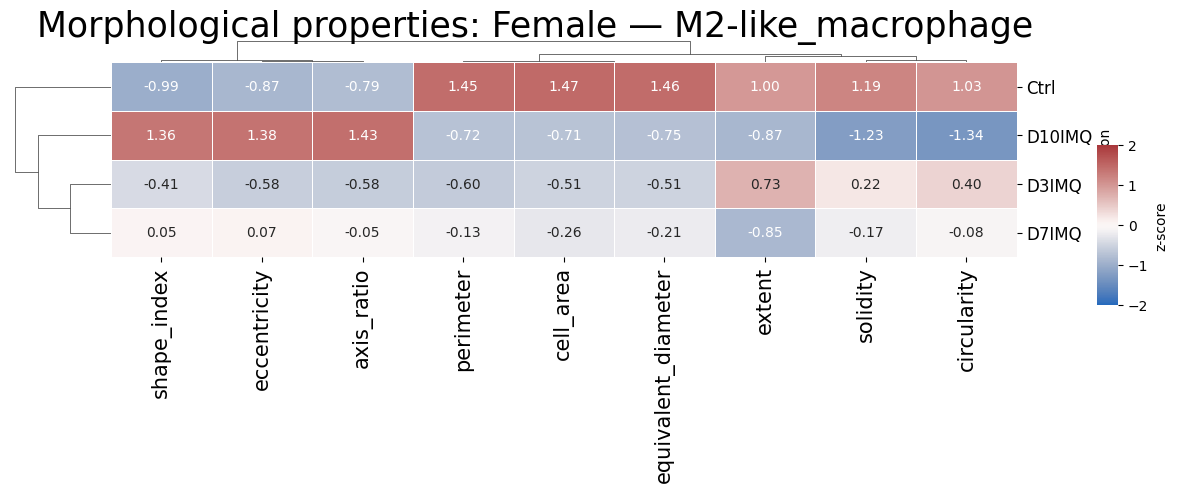

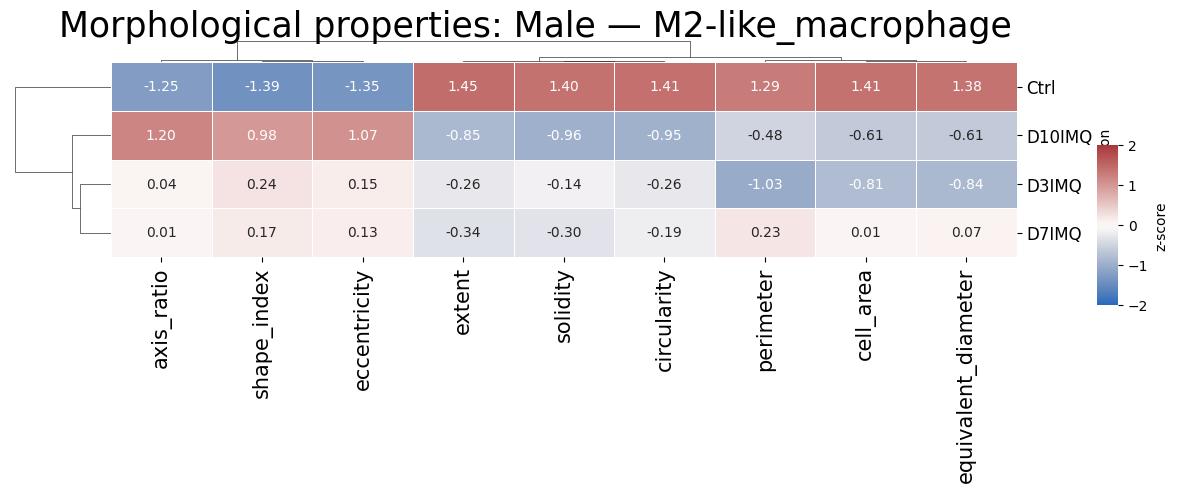

In [3]:
# Cluster map for a given celltype, comparing all properties across samples, splits by sex

#Cluster map of median of features vs sample for a given celltype
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

morph_props = ['cell_area', 'shape_index', 'solidity', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter']

def morph_heatmap(adata, celltype, group_by):
    """
    group_by is the sample grouping to use, either condition (course) or batch_key (fine)
    """
    for sex in ['_F', '_M']:
        data = adata.obs[(adata.obs['celltype_assignments'] == celltype) & (adata.obs['batch_key'].str.contains(sex))]

        # mean per sample per property
        mean_df = data.groupby(group_by, observed=True)[morph_props].median()

        # z-score normalise each property independently (column-wise)
        norm_df = (mean_df - mean_df.mean()) / mean_df.std()

        g = sns.clustermap(norm_df, cmap='vlag', annot=True, fmt='.2f',
                    linewidths=0.5, 
                    cbar_kws={'label': 'z-score'},
                    dendrogram_ratio=0.1,
                    cbar_pos =(1.02, 0.3, 0.02, 0.4),
                    figsize = (len(morph_props)*1.2, len(norm_df)*1.0))
        
        g.ax_heatmap.collections[0].set_clim(-2, 2)
        g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)
        g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=12, rotation=0)
        
        if sex == '_F':
            sexstr = 'Female'
        else:
            sexstr = 'Male'

        g.fig.suptitle(f'Morphological properties: {sexstr} — {celltype}', fontsize = 25, y=1.04)
        plt.show()


morph_heatmap(adata, 'M2-like_macrophage', group_by = 'condition')

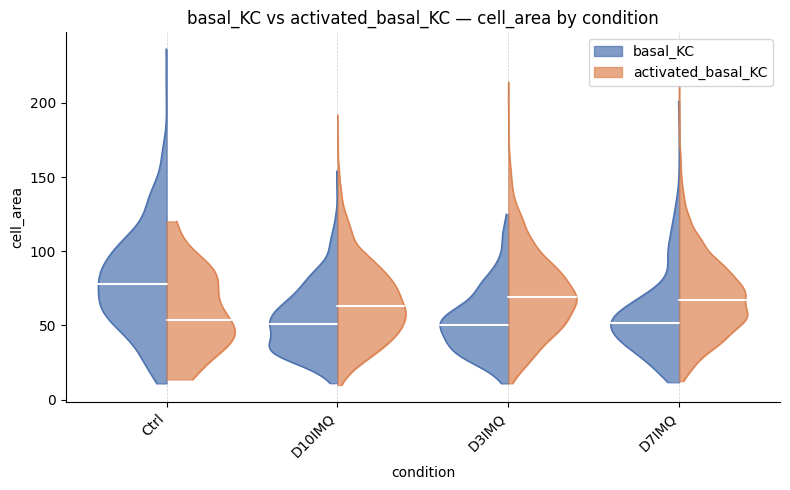

In [4]:
#violin plot of a property across samples (condition or batch_key)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

def violin_across_samples(celltypes, property, adata, grouping, group_order):
    """
    Plot violin plots for given celltypes across groups defined by `grouping` column.
    
    - Single celltype: one violin per group.
    - Two celltypes: split violin per group (left half = celltype 1, right half = celltype 2).
    """
    if group_order:
        group_order = group_order  # your desired order
        groups = sorted(adata.obs[grouping].dropna().unique(),
                key=lambda g: group_order.index(g)) 
    else:
        groups = sorted(adata.obs[grouping].dropna().unique())



    n_groups = len(groups)

    fig, ax = plt.subplots(figsize=(max(8, n_groups * 1.5), 5))
    colors = ['#4C72B0', '#DD8452']

    if len(celltypes) == 1:
        ct = celltypes[0]
        data, labels = [], []
        for grp in groups:
            mask = (adata.obs['celltype_assignments'] == ct) & (adata.obs[grouping] == grp)
            vals = adata.obs.loc[mask, property].dropna().values
            data.append(vals if len(vals) > 0 else np.array([np.nan]))
            labels.append(grp)

        parts = ax.violinplot(data, positions=range(1, n_groups + 1),
                              showmedians=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor(colors[0])
            pc.set_alpha(0.7)

        ax.set_xticks(range(1, n_groups + 1))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_title(f'{ct} — {property} by {grouping}')

    elif len(celltypes) == 2:

        def draw_split_violin(ax, pos, left_data, right_data, width=0.8, color_left='#4C72B0', color_right='#DD8452'):
            """Draw a split violin: left half from left_data, right half from right_data."""
            for data, side, color in [(left_data, 'left', color_left),
                                       (right_data, 'right', color_right)]:
                if len(data) < 2:
                    continue

                kde = gaussian_kde(data, bw_method='scott')
                y_range = np.linspace(data.min(), data.max(), 200)
                density = kde(y_range)
                density = density / density.max() * (width / 2)  # normalise to half-width

                if side == 'left':
                    ax.fill_betweenx(y_range, pos - density, pos, alpha=0.7, color=color)
                    ax.plot(pos - density, y_range, color=color, lw=1)
                else:
                    ax.fill_betweenx(y_range, pos, pos + density, alpha=0.7, color=color)
                    ax.plot(pos + density, y_range, color=color, lw=1)

                # median line
                median = np.median(data)
                half_dens_at_median = kde(median)[0] / kde(y_range).max() * (width / 2)
                if side == 'left':
                    ax.plot([pos - half_dens_at_median, pos], [median, median],
                            color='white', lw=1.5, solid_capstyle='round')
                else:
                    ax.plot([pos, pos + half_dens_at_median], [median, median],
                            color='white', lw=1.5, solid_capstyle='round')

        for i, grp in enumerate(groups):
            pos = i + 1
            vals = []
            for ct in celltypes:
                mask = (adata.obs['celltype_assignments'] == ct) & (adata.obs[grouping] == grp)
                vals.append(adata.obs.loc[mask, property].dropna().values)

            draw_split_violin(ax, pos, left_data=vals[0], right_data=vals[1],
                              color_left=colors[0], color_right=colors[1])

            # centre dividing line
            ax.axvline(pos, color='grey', lw=0.5, linestyle='--', alpha=0.4)

        ax.set_xticks(range(1, n_groups + 1))
        ax.set_xticklabels(groups, rotation=45, ha='right')

        legend_patches = [mpatches.Patch(color=colors[i], alpha=0.7, label=ct)
                          for i, ct in enumerate(celltypes)]
        ax.legend(handles=legend_patches, loc='upper right')
        ax.set_title(f'{" vs ".join(celltypes)} — {property} by {grouping}')

    else:
        raise ValueError("Pass 1 or 2 celltypes.")

    ax.set_xlabel(grouping)
    ax.set_ylabel(property)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

violin_across_samples(['basal_KC', 'activated_basal_KC'], property = 'cell_area', adata = adata, grouping = 'condition', group_order = None)#, group_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ'])

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


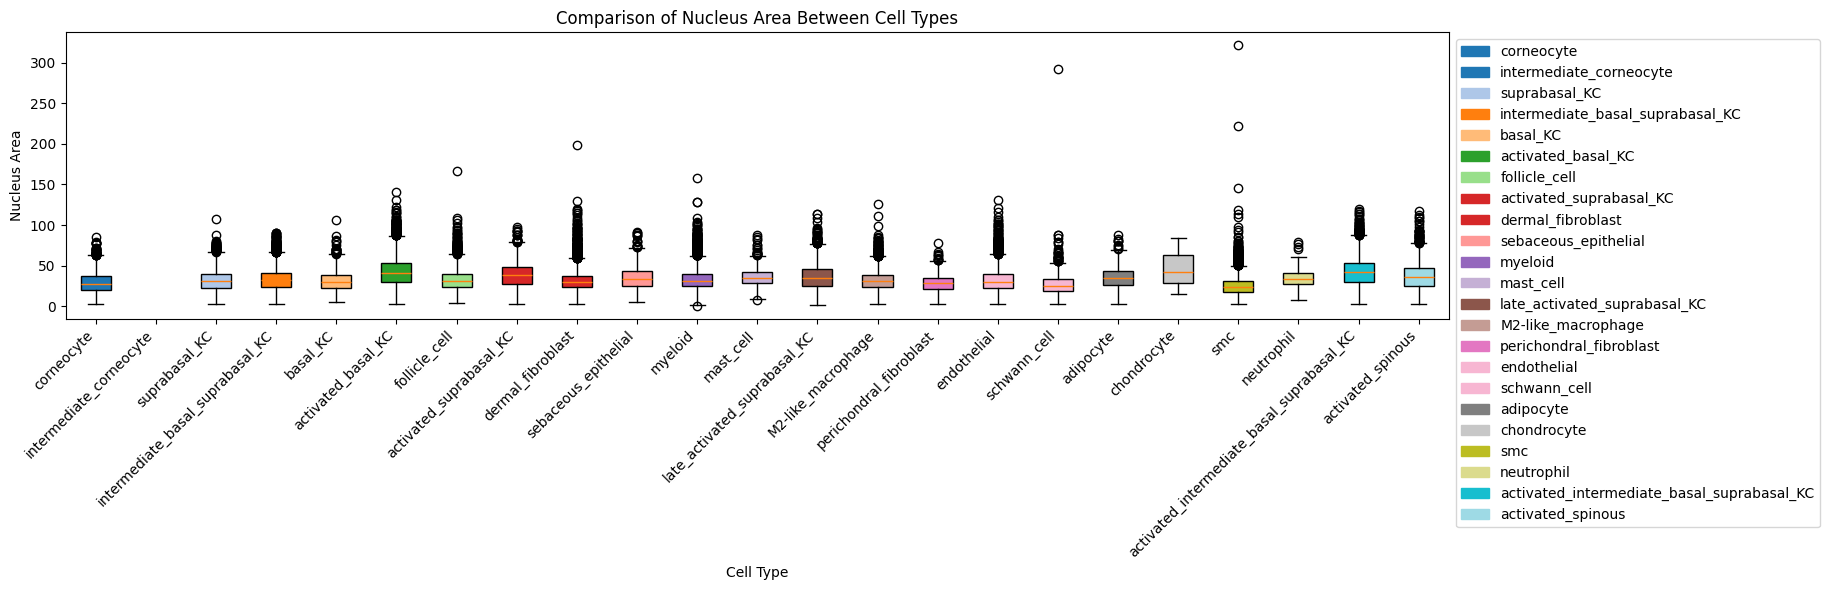

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


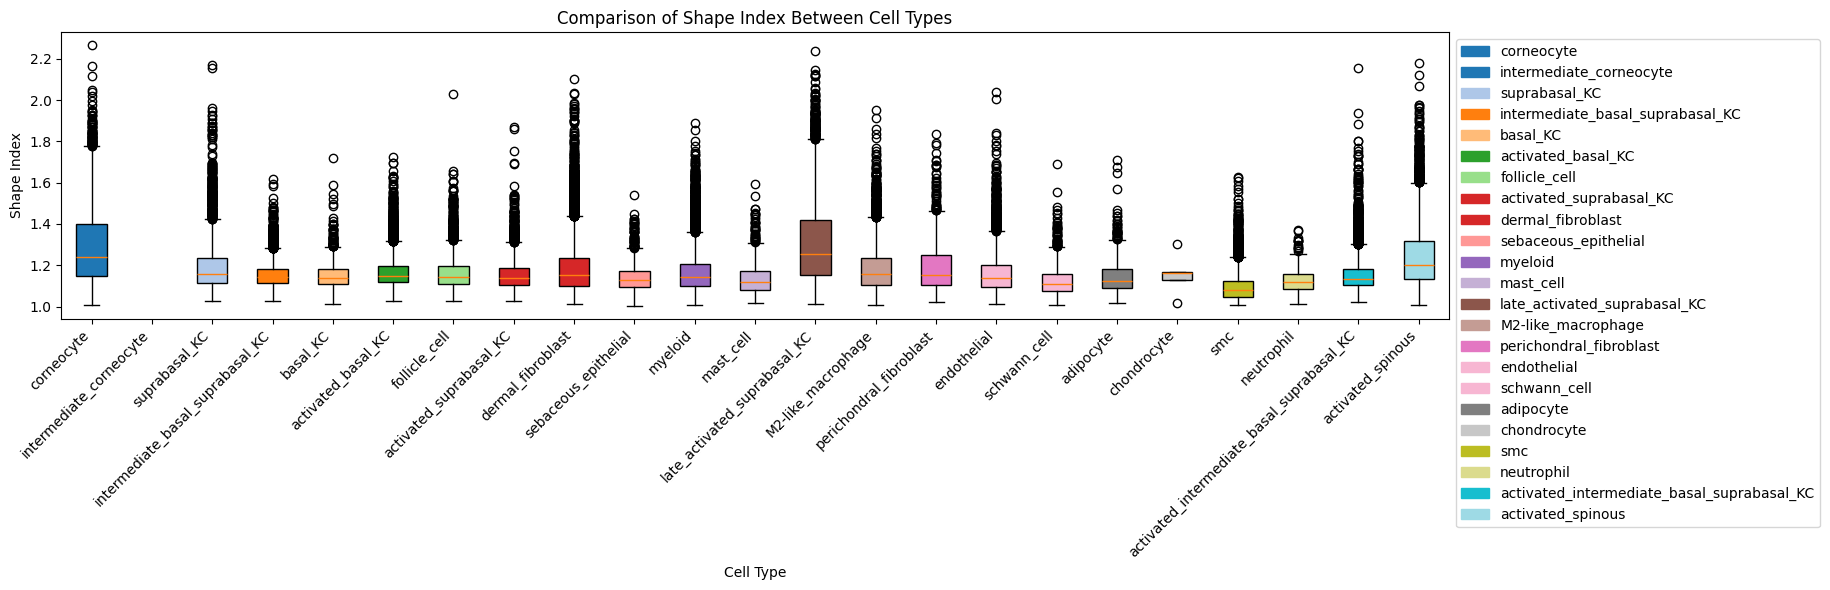

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


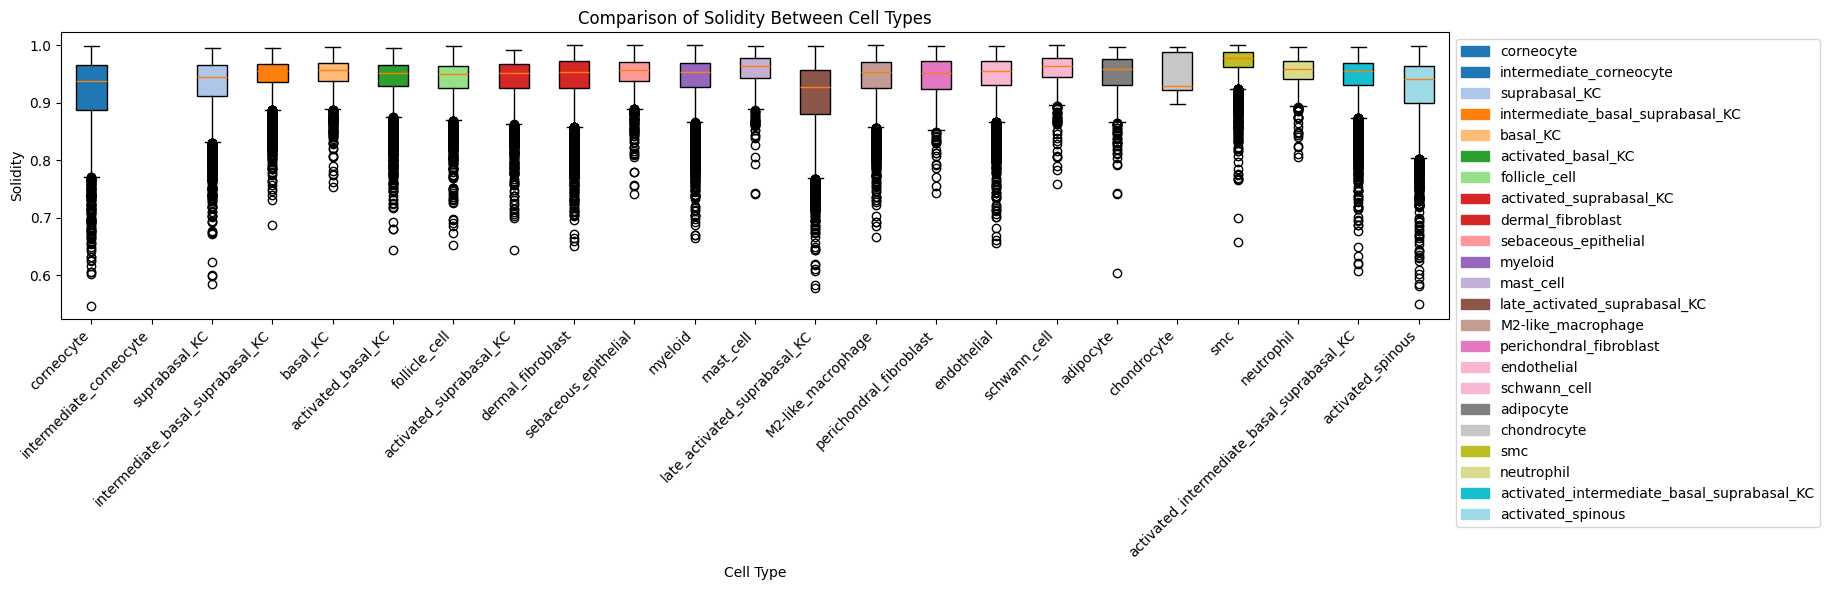

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


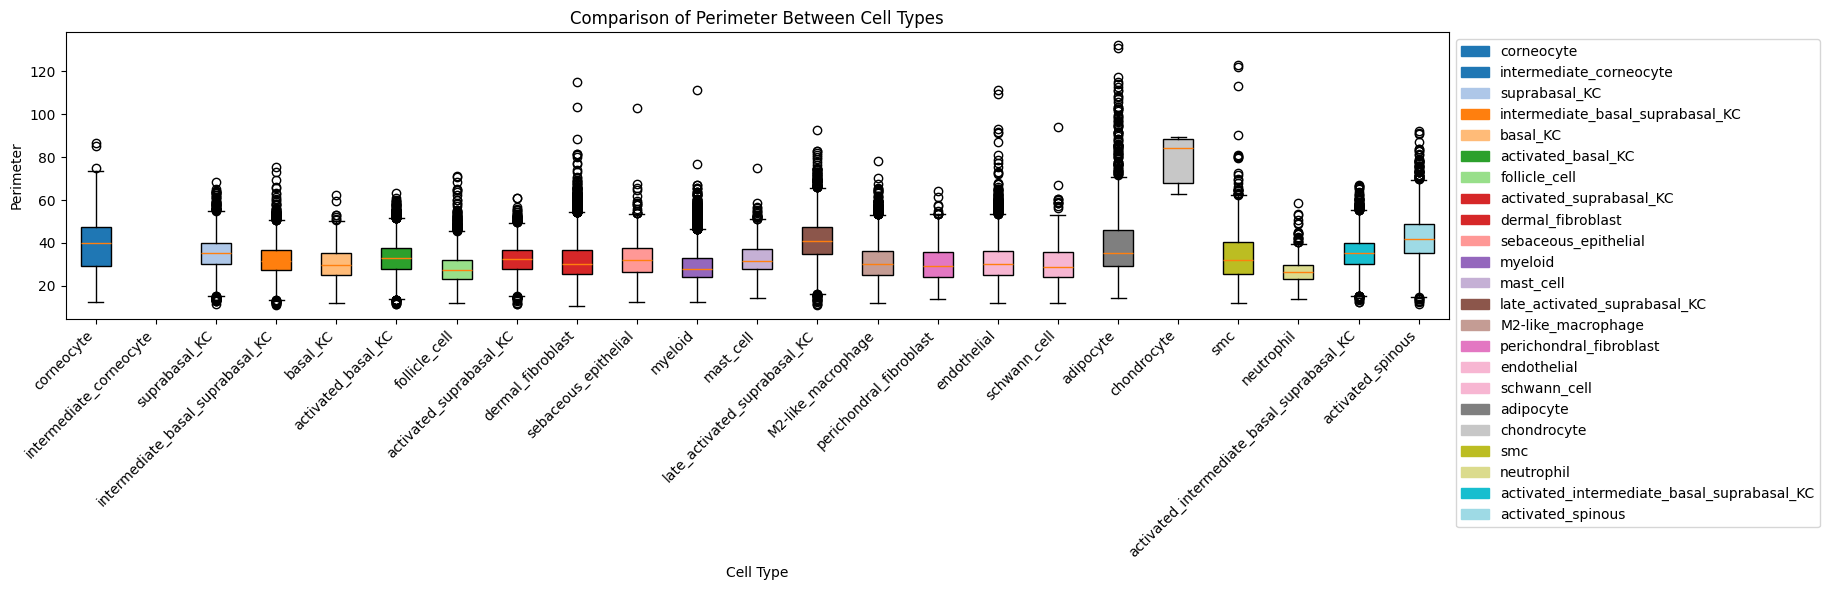

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


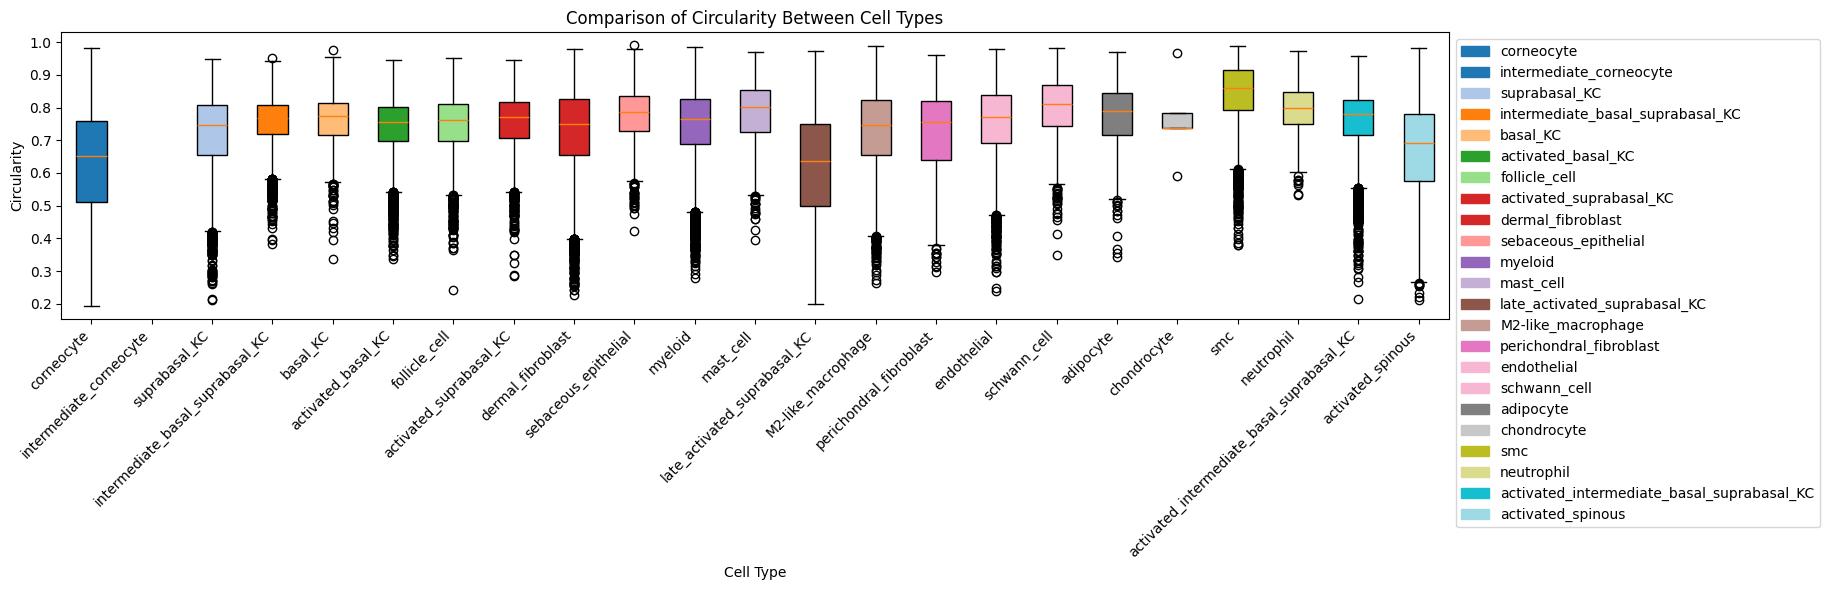

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


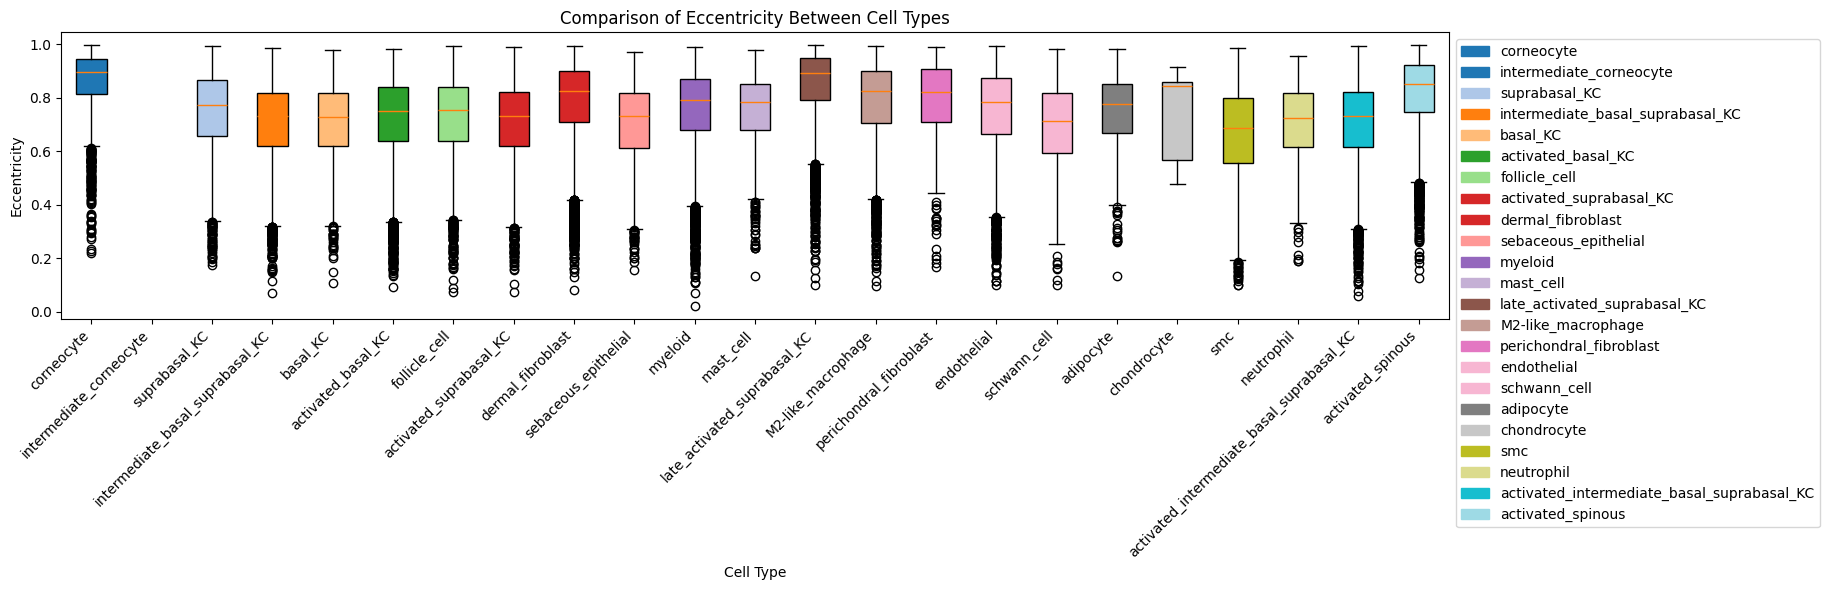

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


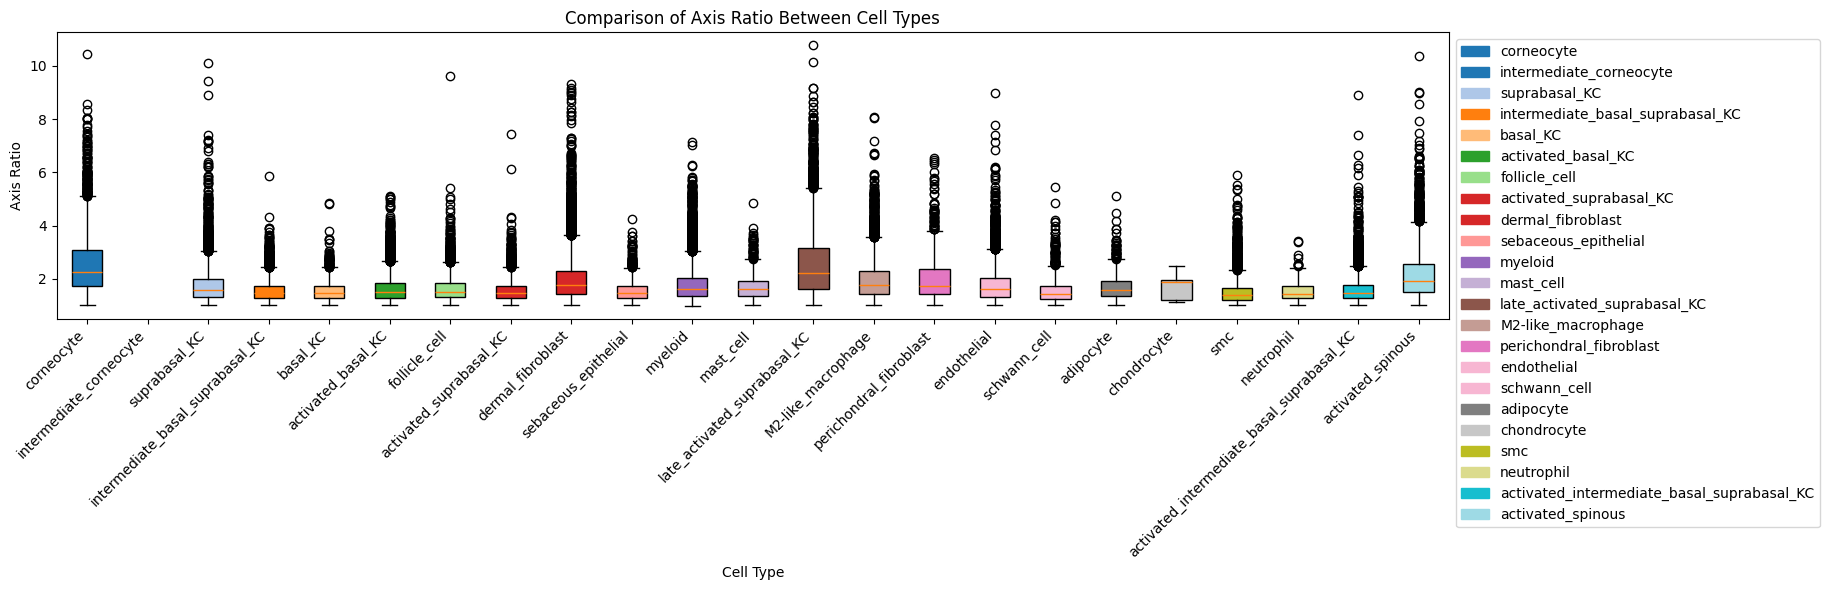

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


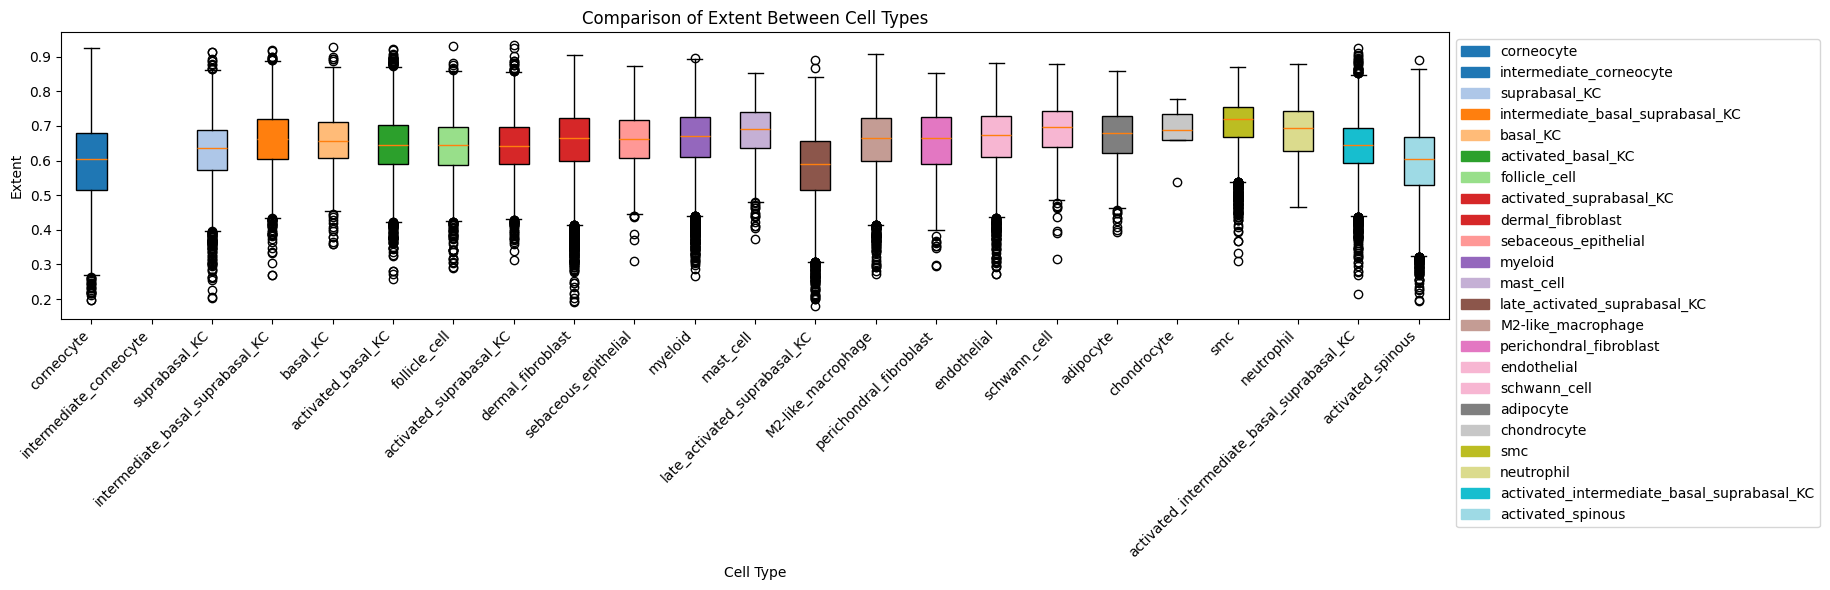

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


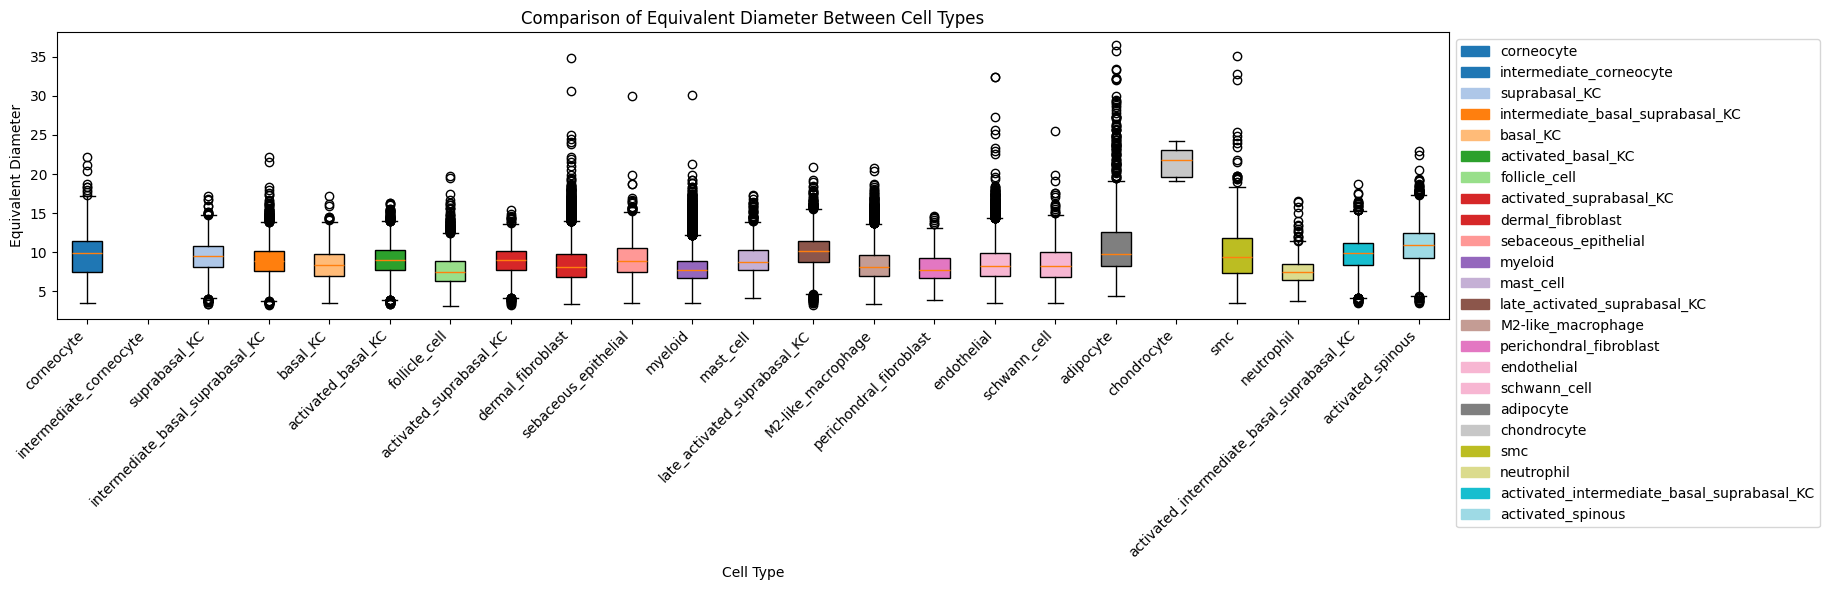

In [6]:
for property in ['nucleus_area', 'shape_index', 'solidity', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter']:
    compare_average(celltypes=['corneocyte',
    'intermediate_corneocyte',
    'suprabasal_KC',
    'intermediate_basal_suprabasal_KC',
    'basal_KC',
    'activated_basal_KC',
    'follicle_cell',
    'activated_suprabasal_KC',
    'dermal_fibroblast',
    'sebaceous_epithelial',
    'myeloid',
    'mast_cell',
    'late_activated_suprabasal_KC',
    'M2-like_macrophage',
    'perichondral_fibroblast',
    'endothelial',
    'schwann_cell',
    'adipocyte',
    'chondrocyte',
    'smc',
    'neutrophil',
    'activated_intermediate_basal_suprabasal_KC',
    'activated_spinous'], property = property, adata = adata)

In [ ]:
adata_f = adata[adata.obs.batch_key.str.contains('_F')].copy()
adata_m = adata[adata.obs.batch_key.str.contains('_M')].copy()
morph_heatmap(adata_f, 'myeloid', group_by = 'condition')
morph_heatmap(adata_m, 'myeloid', group_by = 'condition')


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_29792\1923466174.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = data.groupby(group_by)[morph_props].median()


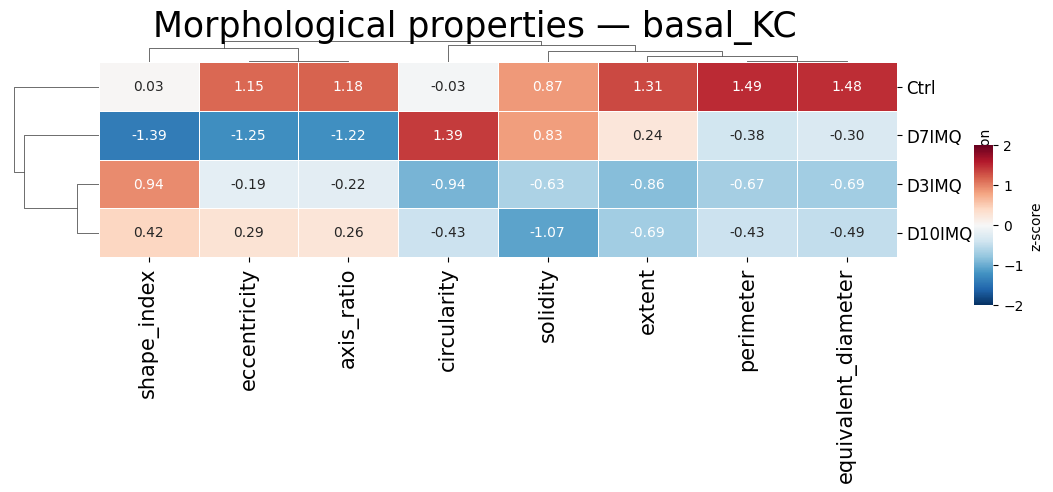

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_29792\1923466174.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = data.groupby(group_by)[morph_props].median()


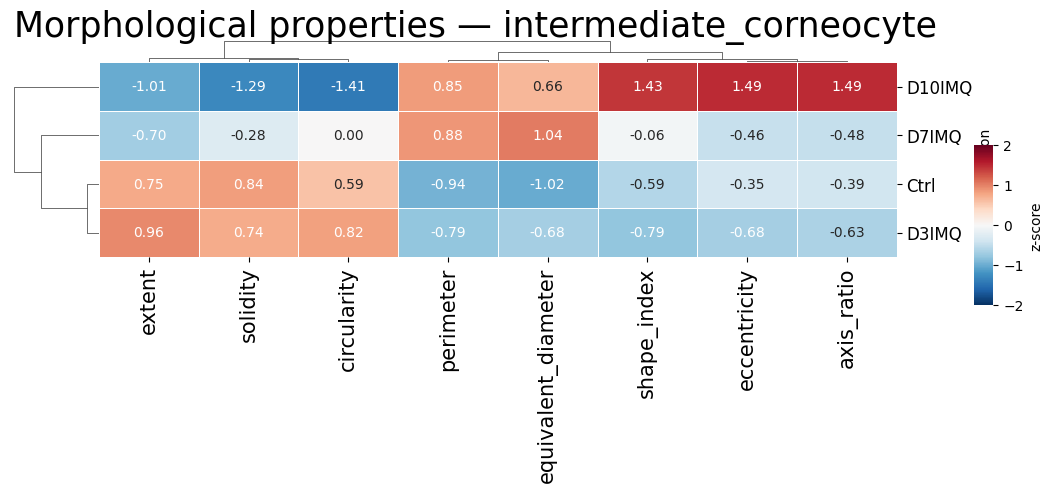

In [30]:
morph_heatmap(adata, 'basal_KC', group_by = 'condition')
morph_heatmap(adata, 'intermediate_corneocyte', group_by = 'condition')



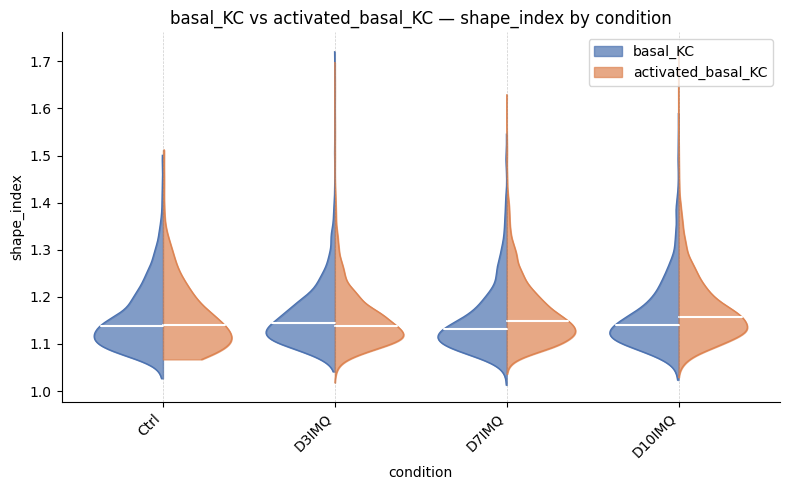

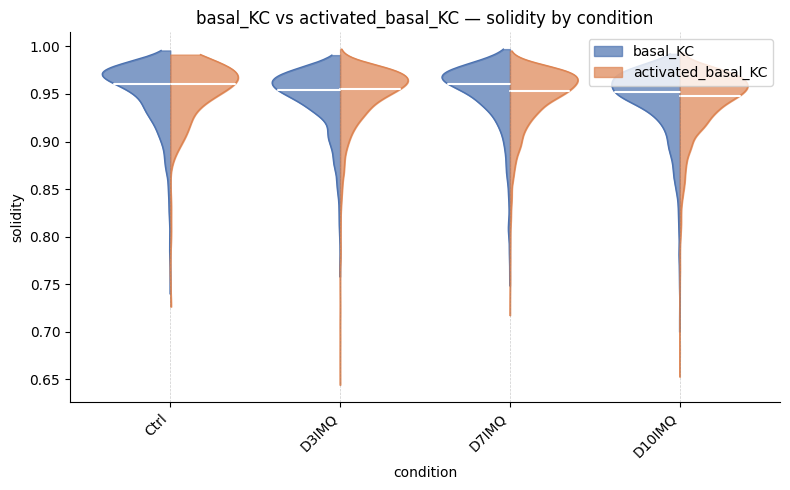

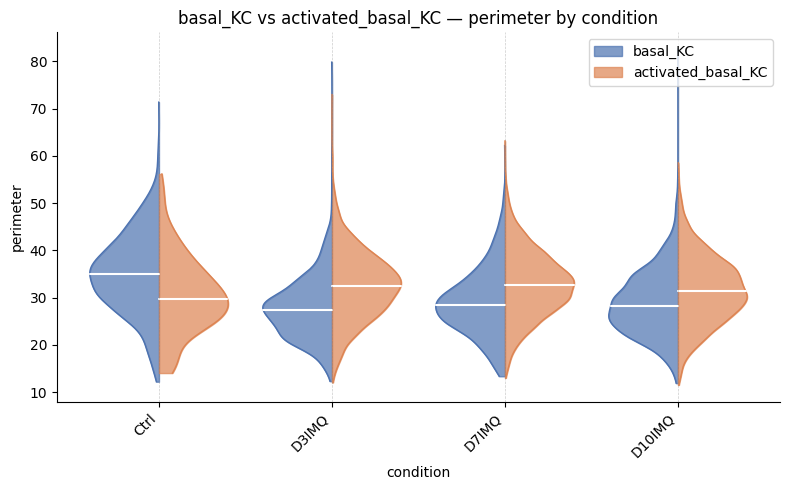

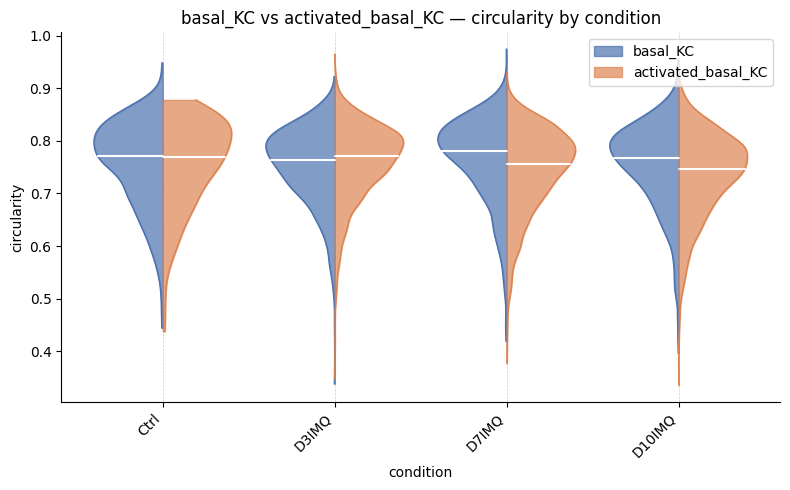

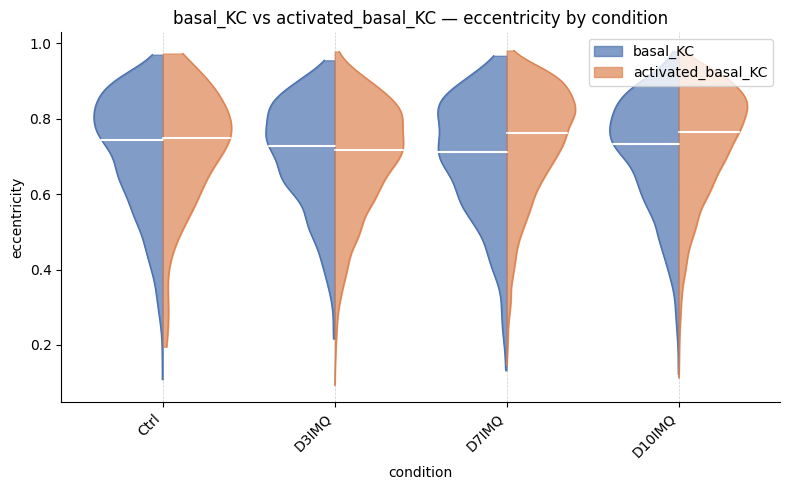

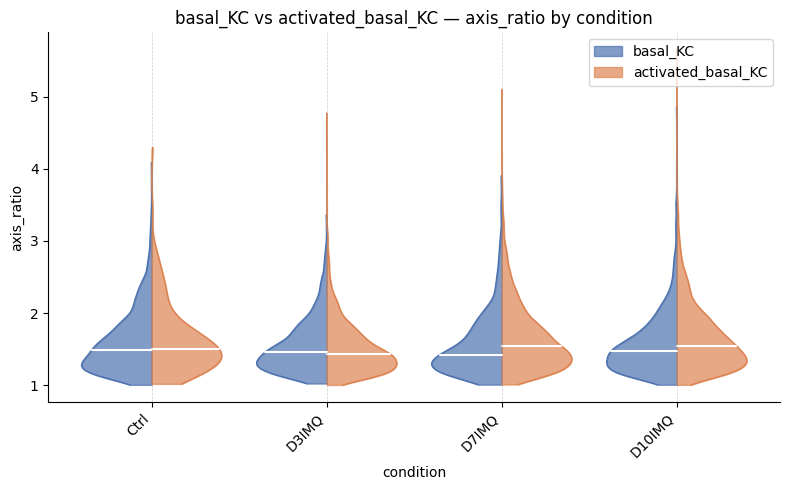

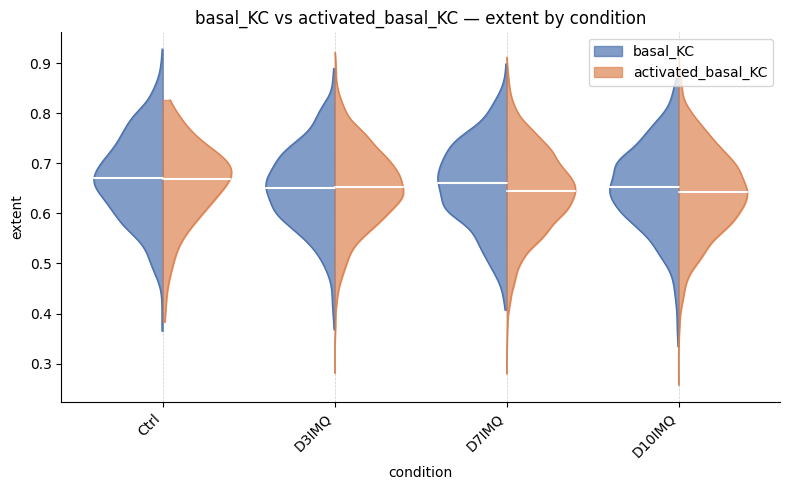

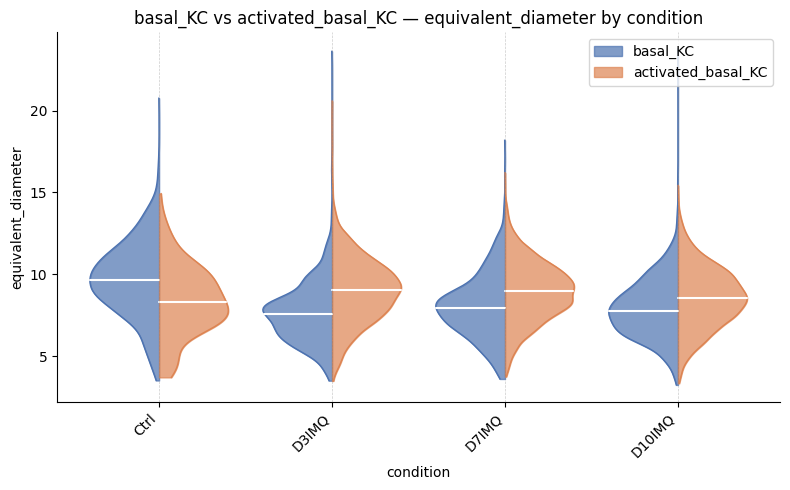

In [7]:
for property in morph_props:
    violin_across_samples(['basal_KC', 'activated_basal_KC'], property = property, adata = adata, grouping = 'condition', group_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ'])

# macrophage investigations

## boxplots over conditions with significance labels - currently a bit wonky
#### plot_property_over_condition_by_sex_boxplot()

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


def plot_property_over_condition_by_sex_boxplot(
    adata,
    celltypes,
    property_name,
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    annotate_stats=True,
    box_width=0.75,
    strip_size=4,
    strip_alpha=0.6,
):
    """
    Boxplot of replicate-level mean property values for multiple cell types,
    split into separate subplots by sex.

    Statistical testing:
    - replicate-level means are computed first
    - within each sex and cell type, Welch's t-test compares Ctrl vs each other condition
    - Benjamini-Hochberg correction is applied across all tests

    Parameters
    ----------
    adata : AnnData
        AnnData object with data in .obs
    celltypes : list
        Cell types to plot
    property_name : str
        Name of the morphological property column in .obs
    celltype_col : str
        Column in .obs containing cell type labels
    batch_col : str
        Column in .obs containing condition_sexreplicate strings, e.g. 'Ctrl_F2'
    condition_order : tuple/list
        Order of conditions on the x-axis
    sex_order : tuple/list
        Order of sexes / subplot order
    figsize : tuple
        Figure size
    annotate_stats : bool
        If True, add BH-adjusted significance stars to the plot
    box_width : float
        Width of the seaborn boxplot groups
    strip_size : int
        Marker size for stripplot points
    strip_alpha : float
        Alpha for stripplot points

    Returns
    -------
    fig, axes, stats_df, summary_df
        stats_df contains the Welch t-test results with BH correction
        summary_df contains replicate-level means
    """

    if property_name not in adata.obs.columns:
        raise KeyError(f"'{property_name}' not found in adata.obs")
    if celltype_col not in adata.obs.columns:
        raise KeyError(f"'{celltype_col}' not found in adata.obs")
    if batch_col not in adata.obs.columns:
        raise KeyError(f"'{batch_col}' not found in adata.obs")

    celltypes = list(celltypes)

    df = adata.obs[[celltype_col, property_name, batch_col]].copy()
    df = df[df[celltype_col].isin(celltypes)].copy()

    if df.empty:
        raise ValueError("No rows found for the requested cell types.")

    # Parse batch_key like 'Ctrl_F2' -> condition='Ctrl', sex='F', replicate='2'
    split_df = df[batch_col].astype(str).str.split("_", n=1, expand=True)
    if split_df.shape[1] < 2:
        raise ValueError(
            f"Could not split '{batch_col}' into condition and sex/replicate using '_'"
        )

    df["condition"] = split_df[0]
    sex_rep = split_df[1]
    df["sex"] = sex_rep.str[0]
    df["replicate"] = sex_rep.str[1:]

    # Keep only expected condition/sex values
    df = df[df["condition"].isin(condition_order)].copy()
    df = df[df["sex"].isin(sex_order)].copy()

    # First average within replicate
    replicate_means = (
        df.groupby([celltype_col, "condition", "sex", batch_col], observed=True)[property_name]
        .mean()
        .reset_index(name="replicate_mean")
    )

    # Color map from AnnData category order
    color_key = f"{celltype_col}_colors"
    if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
        categories = list(adata.obs[celltype_col].cat.categories)
    else:
        categories = list(pd.unique(adata.obs[celltype_col].astype(str)))

    if color_key in adata.uns and len(adata.uns[color_key]) == len(categories):
        color_map = dict(zip(categories, adata.uns[color_key]))
    else:
        cmap = plt.get_cmap("tab20")
        color_map = {ct: cmap(i % 20) for i, ct in enumerate(categories)}

    # Stats: Ctrl vs other conditions within each sex and cell type
    comparisons = []
    pvals = []
    stat_vals = []

    for sex in sex_order:
        for ct in celltypes:
            ctrl_vals = replicate_means[
                (replicate_means[celltype_col] == ct)
                & (replicate_means["sex"] == sex)
                & (replicate_means["condition"] == "Ctrl")
            ]["replicate_mean"].dropna()

            for cond in condition_order[1:]:
                test_vals = replicate_means[
                    (replicate_means[celltype_col] == ct)
                    & (replicate_means["sex"] == sex)
                    & (replicate_means["condition"] == cond)
                ]["replicate_mean"].dropna()

                if len(ctrl_vals) < 2 or len(test_vals) < 2:
                    stat = np.nan
                    p = np.nan
                else:
                    stat, p = ttest_ind(ctrl_vals, test_vals, equal_var=False, nan_policy="omit")

                comparisons.append(
                    {
                        "celltype": ct,
                        "sex": sex,
                        "group1": "Ctrl",
                        "group2": cond,
                        "n_group1": len(ctrl_vals),
                        "n_group2": len(test_vals),
                        "statistic": stat,
                        "p_value": p,
                    }
                )
                stat_vals.append(stat)
                pvals.append(p)

    stats_df = pd.DataFrame(comparisons)

    # BH correction across all valid tests
    valid_mask = stats_df["p_value"].notna()
    if valid_mask.any():
        reject, p_adj, _, _ = multipletests(stats_df.loc[valid_mask, "p_value"].values, method="fdr_bh")
        stats_df.loc[valid_mask, "p_adj"] = p_adj
        stats_df.loc[valid_mask, "reject"] = reject
    else:
        stats_df["p_adj"] = np.nan
        stats_df["reject"] = False

    def p_to_stars(p):
        if pd.isna(p):
            return ""
        if p < 0.0001:
            return "****"
        elif p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return "ns"

    stats_df["stars"] = stats_df["p_adj"].apply(p_to_stars)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    if len(sex_order) != 2:
        raise ValueError("This function currently expects exactly two sexes in sex_order.")

    x = np.arange(len(condition_order))
    n_hues = len(celltypes)
    group_span = 0.8
    per_hue = group_span / max(n_hues, 1)

    # Helper for significance bars
    def add_sig_bar(ax, x1, x2, y, text, h, lw=1.4):
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c="black")
        ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=10)

    sex_titles = {"F": "Female", "M": "Male"}

    for ax, sex in zip(axes, sex_order):
        sex_data = replicate_means[replicate_means["sex"] == sex].copy()

        sns.boxplot(
            data=sex_data,
            x="condition",
            y="replicate_mean",
            hue=celltype_col,
            order=list(condition_order),
            hue_order=celltypes,
            palette=color_map,
            width=box_width,
            ax=ax,
            fliersize=0,
        )

        sns.stripplot(
            data=sex_data,
            x="condition",
            y="replicate_mean",
            hue=celltype_col,
            order=list(condition_order),
            hue_order=celltypes,
            palette=color_map,
            dodge=True,
            size=strip_size,
            alpha=strip_alpha,
            ax=ax,
            linewidth=0,
        )

        ax.set_title(sex_titles.get(sex, sex), fontsize=14)
        ax.set_xlabel("Condition")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Clean up duplicate legends from boxplot + stripplot
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles[:len(celltypes)], labels[:len(celltypes)],
                      title="Cell type", frameon=False, bbox_to_anchor=(1.02, 1),
                      loc="upper left")
        else:
            ax.legend_.remove()

        # Optional significance annotations
        if annotate_stats:
            sex_stats = stats_df[stats_df["sex"] == sex].copy()
            if not sex_stats.empty:
                # Compute y-start based on current data
                y_min = sex_data["replicate_mean"].min()
                y_max = sex_data["replicate_mean"].max()
                y_range = y_max - y_min if y_max > y_min else 1.0
                step = 0.08 * y_range
                h = 0.02 * y_range
                base_y = y_max + 0.06 * y_range

                # For each cell type and each comparison, place a bar above the relevant dodge positions
                for ct_idx, ct in enumerate(celltypes):
                    ct_stats = sex_stats[sex_stats["celltype"] == ct].copy()
                    if ct_stats.empty:
                        continue

                    # approximate dodge offset for this hue
                    offset = -group_span / 2 + (ct_idx + 0.5) * per_hue

                    for comp_idx, cond in enumerate(condition_order[1:]):
                        row = ct_stats[ct_stats["group2"] == cond]
                        if row.empty:
                            continue

                        row = row.iloc[0]
                        stars = row["stars"]
                        if stars == "":
                            continue

                        x1 = 0 + offset
                        x2 = condition_order.index(cond) + offset

                        # vertical stacking so multiple annotations do not overlap
                        y = base_y + (ct_idx * 3 + comp_idx) * step

                        add_sig_bar(ax, x1, x2, y, stars, h)

                # expand y-limits so annotations are visible
                ax.set_ylim(top=base_y + (len(celltypes) * 3 + 3) * step)

    axes[0].set_ylabel(property_name.replace("_", " ").title())
    fig.suptitle(f"{property_name.replace('_', ' ').title()} across conditions", y=1.02)
    fig.tight_layout()

    return fig, axes#, stats_df, replicate_means

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_27936\1781293163.py:107: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Female'}, xlabel='Condition', ylabel='Cell Area'>,
        <Axes: title={'center': 'Male'}, xlabel='Condition', ylabel='replicate_mean'>],
       dtype=object))

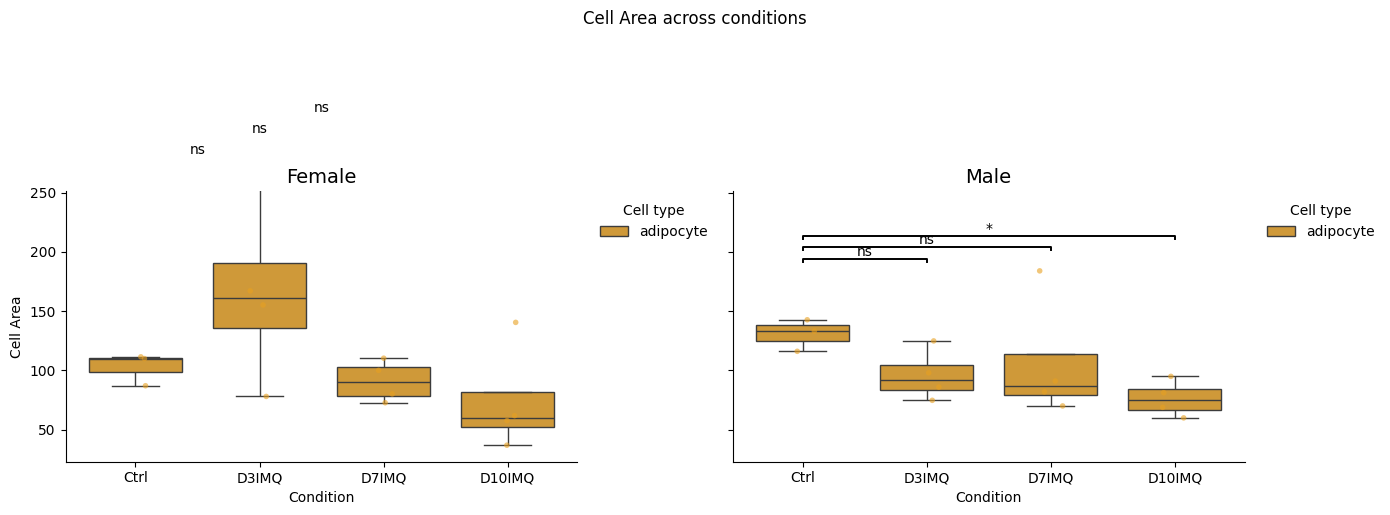

In [80]:
plot_property_over_condition_by_sex_boxplot(
    adata,
    celltypes = ['adipocyte'],
    property_name = 'cell_area',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    annotate_stats=True,
    box_width=0.75,
    strip_size=4,
    strip_alpha=0.6,
)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_27936\1781293163.py:107: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Female'}, xlabel='Condition', ylabel='Cell Area'>,
        <Axes: title={'center': 'Male'}, xlabel='Condition', ylabel='replicate_mean'>],
       dtype=object))

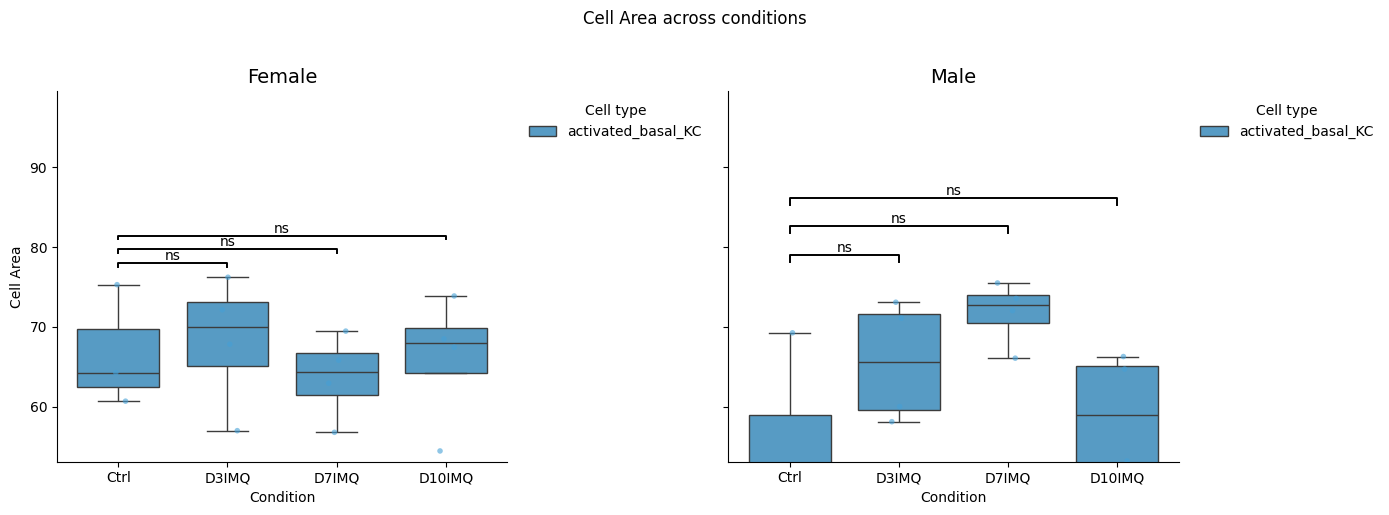

In [64]:
plot_property_over_condition_by_sex_boxplot(
    adata,
    celltypes = ['activated_basal_KC'],
    property_name = 'cell_area',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    annotate_stats=True,
    box_width=0.75,
    strip_size=4,
    strip_alpha=0.6,
)

## mean + SE plot of celltype property over conditions, with option for multiple celltypes
#### plot_property_over_condition_by_sex()

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_property_over_condition_by_sex(
    adata,
    celltypes,
    property_name,
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    marker_size=7,
    line_width=2,
    capsize=4,
):
    """
    Plot mean +/- SEM of a morphological property for multiple cell types
    across conditions, split into separate subplots by sex.

    Parameters
    ----------
    adata : AnnData
        AnnData object with data in .obs
    celltypes : list
        List of cell types to plot
    property_name : str
        Name of the morphological property column in .obs
    celltype_col : str
        Column in .obs containing cell type labels
    batch_col : str
        Column in .obs containing condition_sexreplicate strings, e.g. 'Ctrl_F2'
    condition_order : tuple/list
        Order of conditions on the x-axis
    sex_order : tuple/list
        Order of sexes / subplot order
    figsize : tuple
        Figure size

    Returns
    -------
    fig, axes, summary
        summary is a dataframe with replicate-level means and condition-level mean/SEM
    """

    if property_name not in adata.obs.columns:
        raise KeyError(f"'{property_name}' not found in adata.obs")
    if celltype_col not in adata.obs.columns:
        raise KeyError(f"'{celltype_col}' not found in adata.obs")
    if batch_col not in adata.obs.columns:
        raise KeyError(f"'{batch_col}' not found in adata.obs")

    celltypes = list(celltypes)

    # Keep only the requested cell types
    df = adata.obs[[celltype_col, property_name, batch_col]].copy()
    df = df[df[celltype_col].isin(celltypes)].copy()

    if df.empty:
        raise ValueError("No rows found for the requested cell types.")

    # Parse batch_key like 'Ctrl_F2' -> condition='Ctrl', sex='F', replicate='2'
    split_df = df[batch_col].astype(str).str.split("_", n=1, expand=True)
    if split_df.shape[1] < 2:
        raise ValueError(
            f"Could not split '{batch_col}' into condition and sex/replicate using '_'"
        )

    df["condition"] = split_df[0]
    sex_rep = split_df[1]
    df["sex"] = sex_rep.str[0]
    df["replicate"] = sex_rep.str[1:]

    # Keep only expected condition/sex values
    df = df[df["condition"].isin(condition_order)].copy()
    df = df[df["sex"].isin(sex_order)].copy()

    # Step 1: average across cells within each biological replicate
    replicate_means = (
        df.groupby([celltype_col, "condition", "sex", batch_col], observed=True)[property_name]
        .mean()
        .reset_index(name="replicate_mean")
    )

    # Step 2: mean and SEM across replicates
    def sem(x):
        x = x.dropna()
        n = x.shape[0]
        if n <= 1:
            return 0.0
        return x.std(ddof=1) / np.sqrt(n)

    summary = (
        replicate_means.groupby([celltype_col, "condition", "sex"], observed=True)
        .agg(
            mean_property=("replicate_mean", "mean"),
            sem_property=("replicate_mean", sem),
            n_replicates=("replicate_mean", "count"),
        )
        .reset_index()
    )

    # Build color map from adata.uns['celltype_assignments_colors']
    if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
        categories = list(adata.obs[celltype_col].cat.categories)
    else:
        categories = list(pd.unique(adata.obs[celltype_col].astype(str)))

    colors = adata.uns[f"{celltype_col}_colors"]
    color_map = dict(zip(categories, colors))


    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    if len(sex_order) != 2:
        raise ValueError("This function currently expects exactly two sexes in sex_order.")

    x = np.arange(len(condition_order))
    sex_titles = {"F": "Female", "M": "Male"}

    for ax, sex in zip(axes, sex_order):
        for ct in celltypes:
            ct_data = summary[(summary[celltype_col] == ct) & (summary["sex"] == sex)].copy()
            ct_data["condition"] = pd.Categorical(
                ct_data["condition"], categories=list(condition_order), ordered=True
            )
            ct_data = ct_data.sort_values("condition").set_index("condition").reindex(condition_order)

            means = ct_data["mean_property"].to_numpy()
            sems = ct_data["sem_property"].to_numpy()

            if np.all(np.isnan(means)):
                continue

            color = color_map.get(ct, "grey")
            label = ct.replace("_", " ")

            ax.plot(
                x,
                means,
                marker="o",
                linewidth=line_width,
                markersize=marker_size,
                color=color,
                label=label,
            )
            ax.errorbar(
                x,
                means,
                yerr=sems,
                fmt="none",
                ecolor=color,
                elinewidth=1.8,
                capsize=capsize,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(condition_order)
        ax.set_xlabel("Condition")
        ax.set_title(sex_titles.get(sex, sex))
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(property_name.replace("_", " ").title())

    # One shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            title="Cell type",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=False,
        )

    fig.suptitle(f"{property_name.replace('_', ' ').title()} across conditions", y=1.02)
    fig.tight_layout()

    return fig, axes, #summary

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Female'}, xlabel='Condition', ylabel='Eccentricity'>,
        <Axes: title={'center': 'Male'}, xlabel='Condition'>], dtype=object))

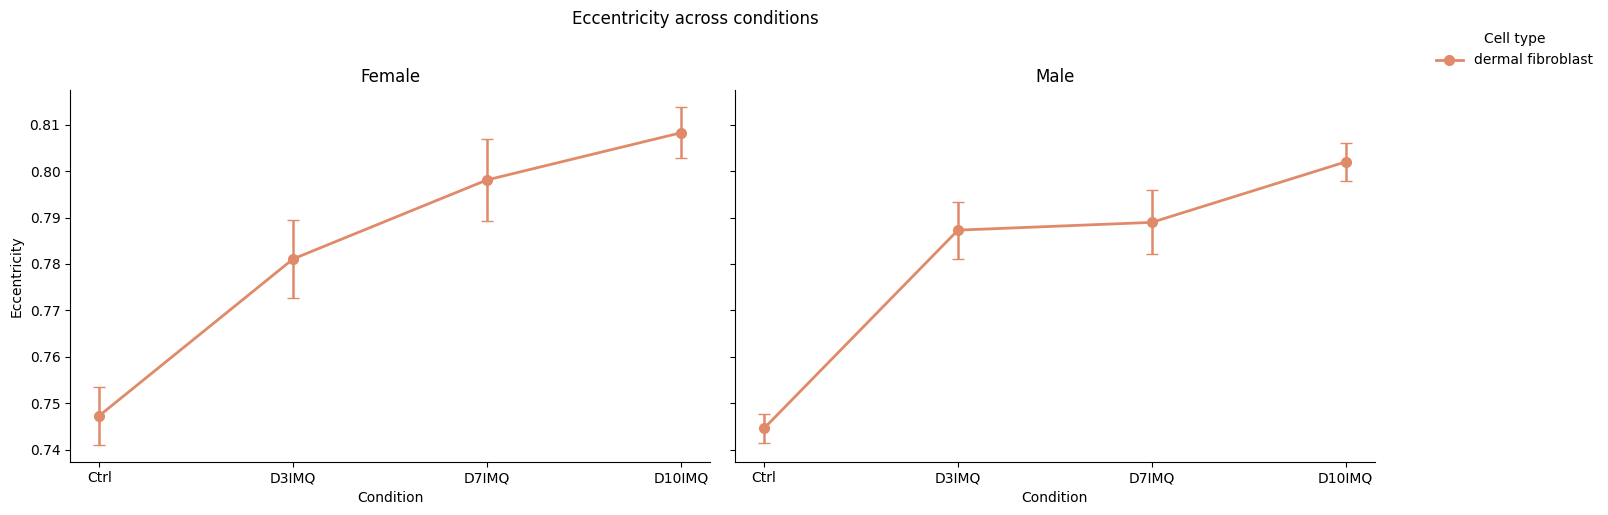

In [49]:
plot_property_over_condition_by_sex(
    adata,
    celltypes = ['dermal_fibroblast'],
    property_name = 'eccentricity',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    marker_size=7,
    line_width=2,
    capsize=4,
)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_27936\883563515.py:106: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Female'}, xlabel='Condition', ylabel='Cell Area'>,
        <Axes: title={'center': 'Male'}, xlabel='Condition'>], dtype=object))

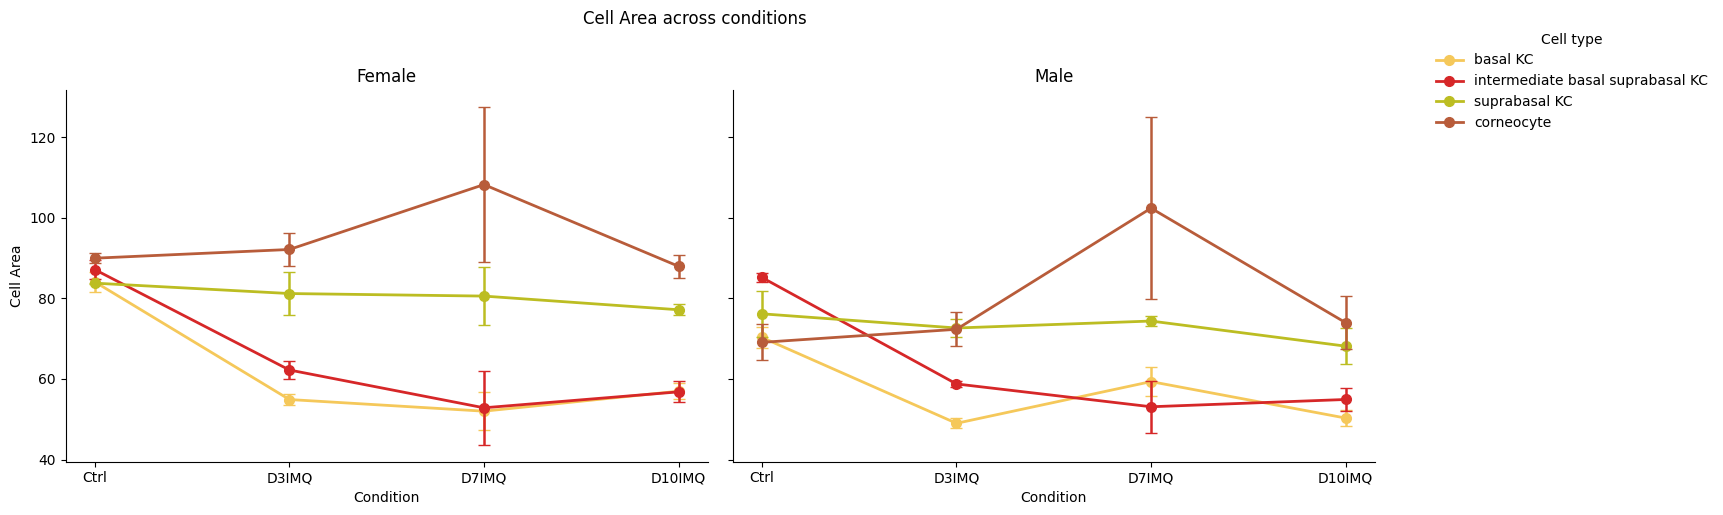

In [50]:
plot_property_over_condition_by_sex(
    adata,
    celltypes = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte'],
    property_name = 'cell_area',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    marker_size=7,
    line_width=2,
    capsize=4,
)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_27936\883563515.py:106: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Female'}, xlabel='Condition', ylabel='Cell Area'>,
        <Axes: title={'center': 'Male'}, xlabel='Condition'>], dtype=object))

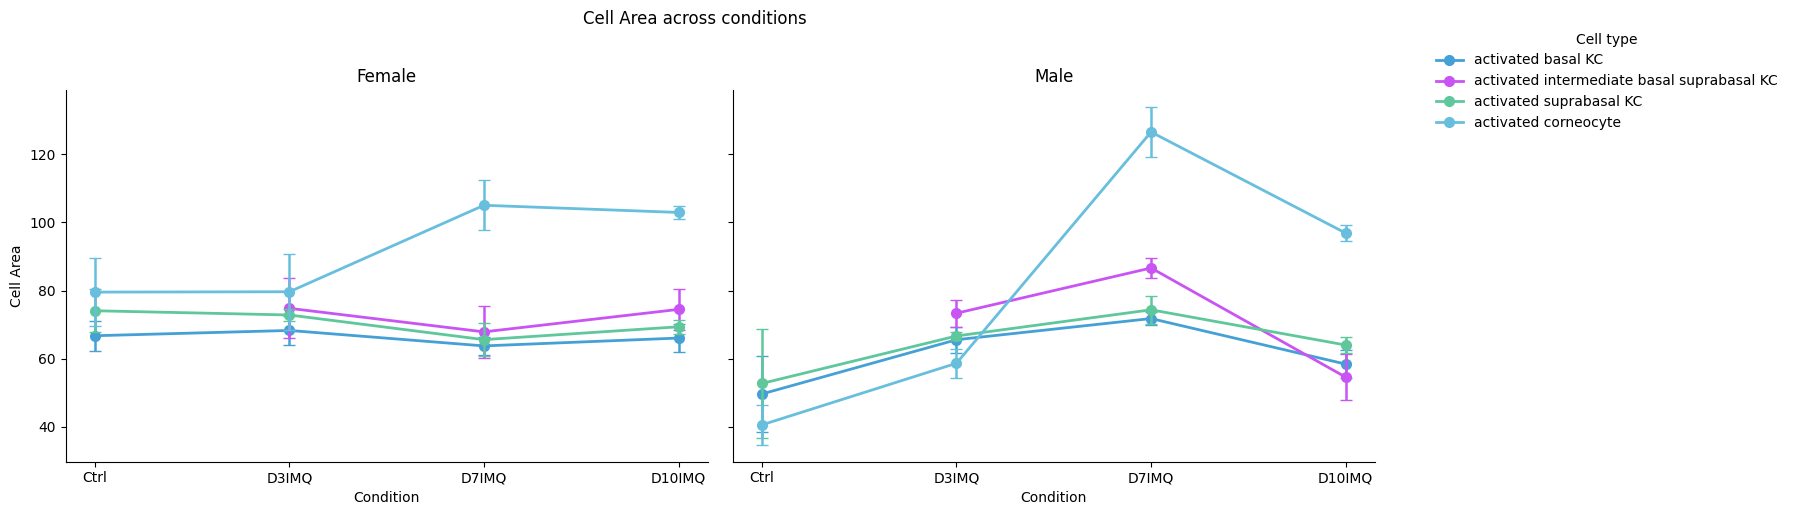

In [90]:
plot_property_over_condition_by_sex(
    adata,
    celltypes = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte'],
    property_name = 'cell_area',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    marker_size=7,
    line_width=2,
    capsize=4,
)

# MuSpAn for wPCF

In [31]:
#making MuSpAn domains
import muspan as ms
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
adata = adata[adata.obs['compartment'].str.contains('orsal')]

replicates = {}
for rep in adata.obs.batch_key.unique():
    replicates[rep] = adata[adata.obs.batch_key == rep].copy()

#DEFINE PROPERTY FOR wPCF
morph_prop = 'solidity'

In [32]:
#dictionary of domains
rep_domains = {}
for name, rep in replicates.items():
    rep_domains[name] = ms.domain(f'{name}')

#add points, these will be in um if taken from xenium data
for name, domain in rep_domains.items():
    points = replicates[name].obsm['spatial']
    domain.add_points(points, 'cells')


#add cell labels
for name, domain in rep_domains.items():
    labels = replicates[name].obs.celltype_assignments.to_numpy()
    domain.add_labels('celltype_assignments', labels)

#add morphological labels
for name, domain in rep_domains.items():
    morph_labels = replicates[name].obs[morph_prop].to_numpy()
    domain.add_labels(morph_prop, labels = morph_labels)

#estimate boundary using alphashape -- could also use compartment segmentations, similar results, given they are both defined by cell existence. 
for domain in rep_domains.values():
    domain.estimate_boundary(method = 'alpha shape',
                             alpha_shape_kwargs = {'alpha': 150})

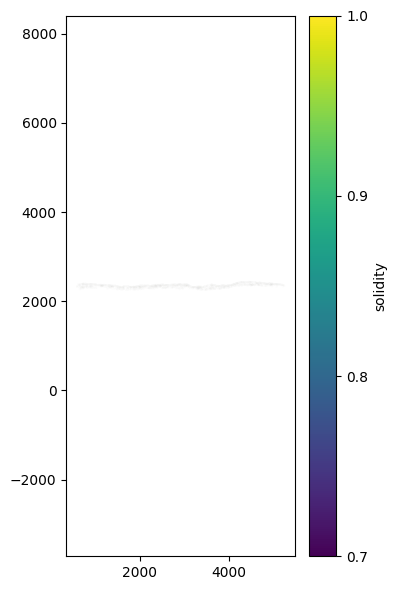

In [ ]:
#visualisation sense check
for name, domain in sorted(rep_domains.items()):
    ms.visualise.visualise(domain, color_by=morph_prop,figure_kwargs={'figsize': (4, 6)})
    
    break

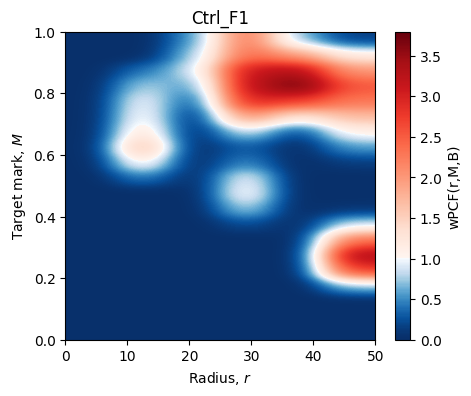

In [18]:
for name, domain in sorted(rep_domains.items()):
    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'myeloid')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
    domain, cellA, cellB, mark_pop_B=morph_prop, max_R=50, annulus_step=10, annulus_width=10
    )       

    # Visualize the weighted pair correlation function (wPCF)
    fig, ax = ms.visualise.visualise_wpcf(radii, wPCF, figure_kwargs={'figsize': (5, 4)})

    ax.set_title(name)

    # Plot the expected value of the target mark M (M = r^2) as a function of r
    #plt.gca().plot(np.arange(0, 1, 0.01), np.arange(0, 1, 0.01) ** 2, color=[0, 0, 0], linestyle=':', lw=5)
    break
    

### Gemini way of averaging wPCF

----------------------------------------


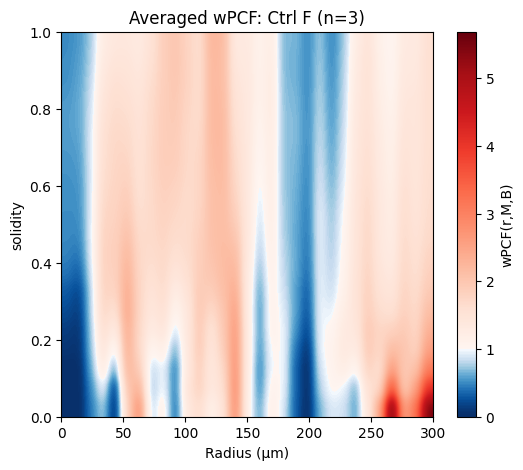

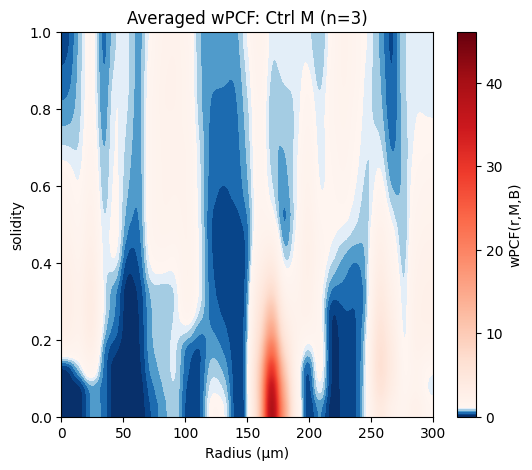

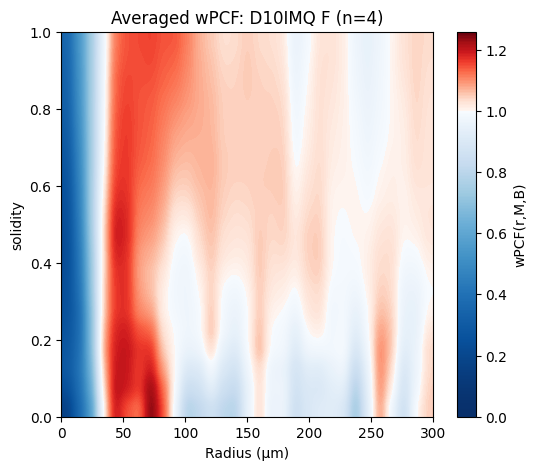

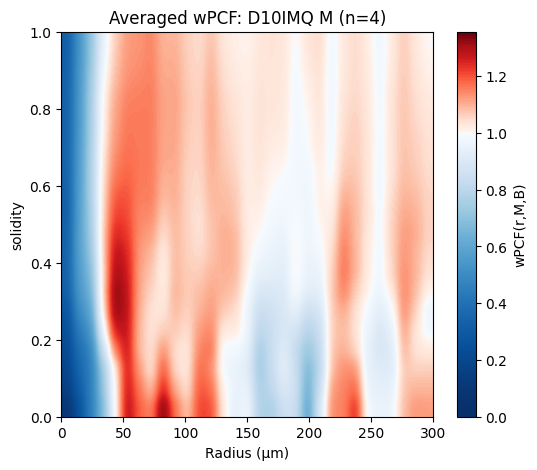

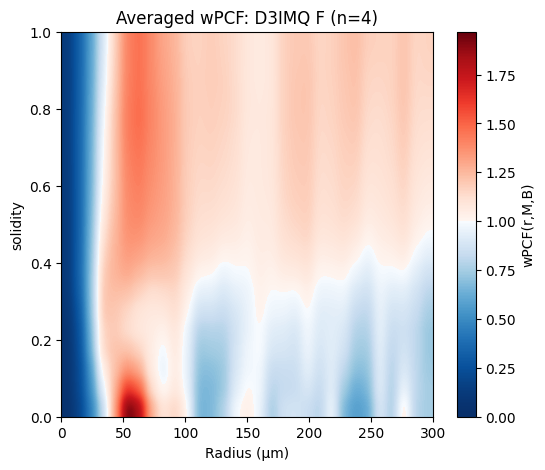

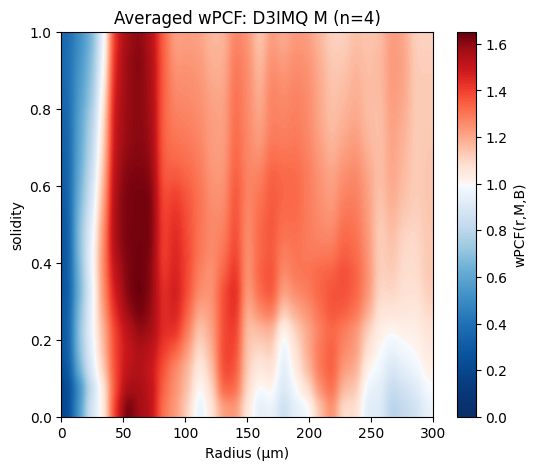

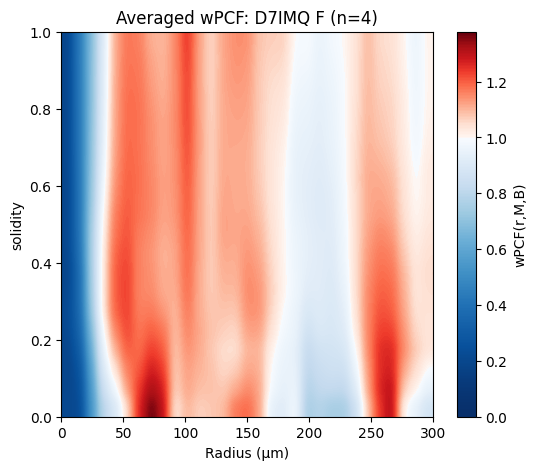

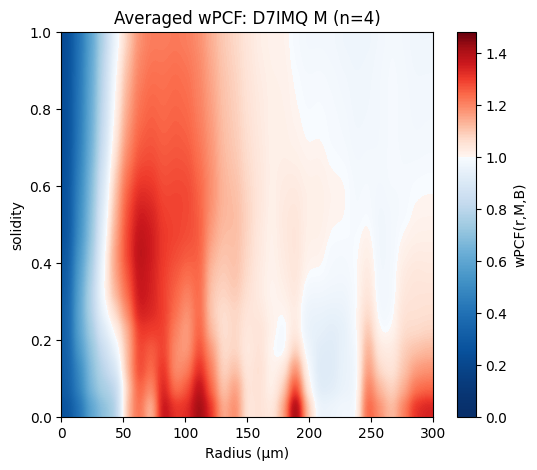

In [39]:
import numpy as np
import re
import matplotlib.pyplot as plt

"""GLOBAL_AREA_MIN = 0     
GLOBAL_AREA_MAX = 300 
GLOBAL_AREA_STEP = 25   """ #only use if trying to get area to work

grouped_wpcfs = {}
shared_radii = None

for name, domain in sorted(rep_domains.items()):
    
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
        
    group_key = match.group(1) 
    
    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'myeloid')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB, 
        mark_pop_B=morph_prop, 
        max_R=300, 
        annulus_step=10, 
        annulus_width=15,
        # mark_min_pop_B=GLOBAL_AREA_MIN,   
        # mark_max_pop_B=GLOBAL_AREA_MAX,   
        # mark_step_pop_B=GLOBAL_AREA_STEP  
    )       
    
    
    # 2. Keep the longest radii array for the final visualization
    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

print("-" * 40)

# 3. Average the arrays with NaN Padding
averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    
    # Find the maximum rows and columns for this group
    max_rows = max([arr.shape[0] for arr in wpcf_list])
    max_cols = max([arr.shape[1] for arr in wpcf_list])
    
    padded_list = []
    
    for arr in wpcf_list:
        # Calculate how much padding is needed for rows and cols
        pad_rows = max_rows - arr.shape[0]
        pad_cols = max_cols - arr.shape[1]
        
        # Pad the bottom and right edges with NaNs
        padded_arr = np.pad(
            arr, 
            ((0, pad_rows), (0, pad_cols)), 
            mode='constant', 
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    # Now all arrays in the list are the exact same shape, so this will work:
    avg_wpcf = np.nanmean(padded_list, axis=0)
    averaged_wpcfs[group_key] = avg_wpcf
    
    
    fig, ax = ms.visualise.visualise_wpcf(
        shared_radii, 
        avg_wpcf, 
        figure_kwargs={'figsize': (6, 5)}
    )


    ax.set_title(f"Averaged wPCF: {group_key.replace("_", " ")} (n={len(wpcf_list)})")
    ax.set_ylabel(f"{morph_prop.replace("_", " ")}")
    ax.set_xlabel("Radius (µm)")
    
    plt.show()

----------------------------------------


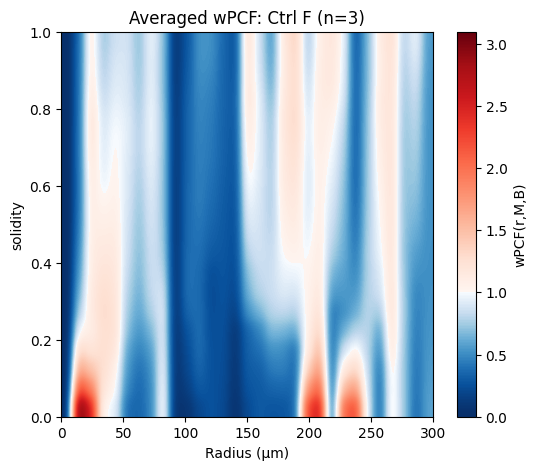

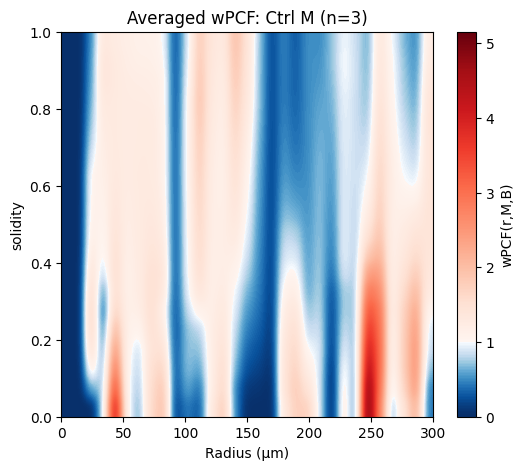

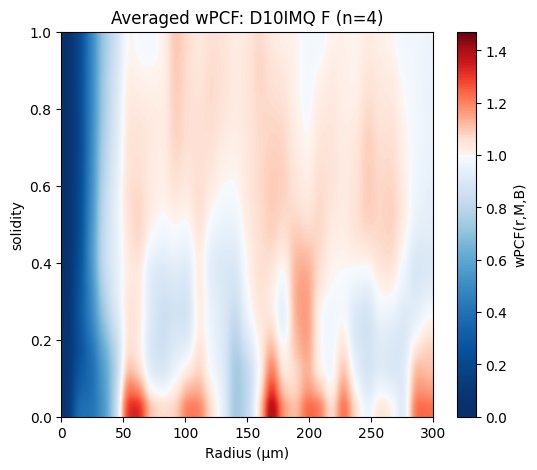

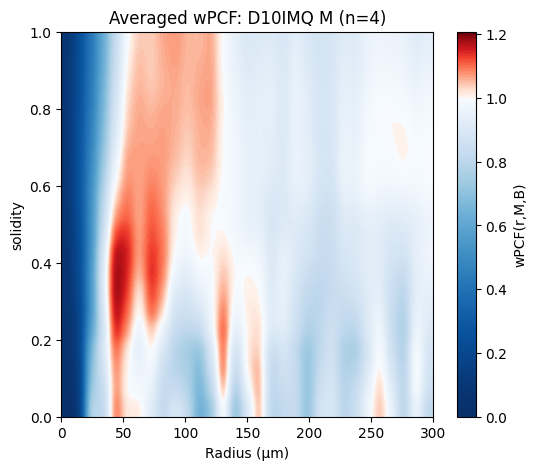

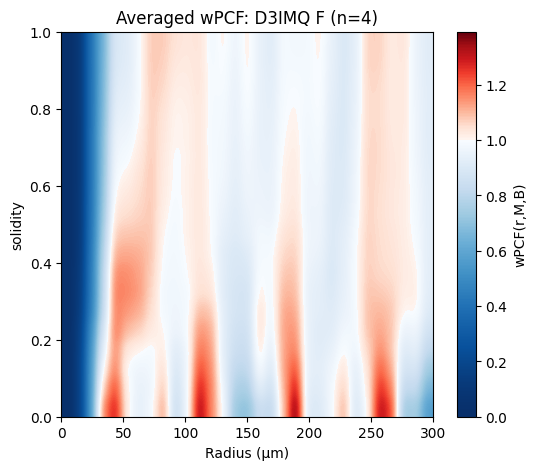

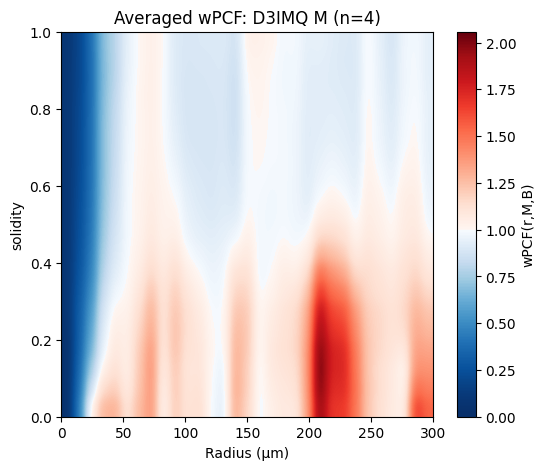

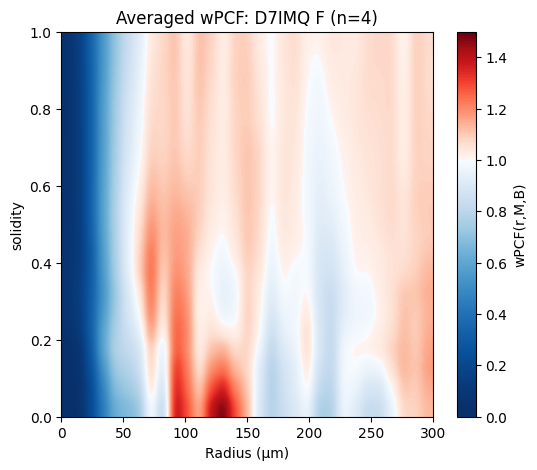

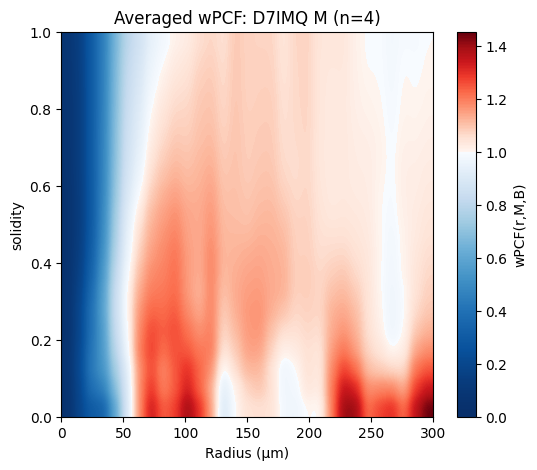

In [40]:
import numpy as np
import re
import matplotlib.pyplot as plt

"""GLOBAL_AREA_MIN = 0     
GLOBAL_AREA_MAX = 300 
GLOBAL_AREA_STEP = 25   """ #only use if trying to get area to work

grouped_wpcfs = {}
shared_radii = None

for name, domain in sorted(rep_domains.items()):
    
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
        
    group_key = match.group(1) 
    
    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'M2-like_macrophage')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB, 
        mark_pop_B=morph_prop, 
        max_R=300, 
        annulus_step=10, 
        annulus_width=15,
        # mark_min_pop_B=GLOBAL_AREA_MIN,   
        # mark_max_pop_B=GLOBAL_AREA_MAX,   
        # mark_step_pop_B=GLOBAL_AREA_STEP  
    )       
    
    
    # 2. Keep the longest radii array for the final visualization
    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

print("-" * 40)

# 3. Average the arrays with NaN Padding
averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    
    # Find the maximum rows and columns for this group
    max_rows = max([arr.shape[0] for arr in wpcf_list])
    max_cols = max([arr.shape[1] for arr in wpcf_list])
    
    padded_list = []
    
    for arr in wpcf_list:
        # Calculate how much padding is needed for rows and cols
        pad_rows = max_rows - arr.shape[0]
        pad_cols = max_cols - arr.shape[1]
        
        # Pad the bottom and right edges with NaNs
        padded_arr = np.pad(
            arr, 
            ((0, pad_rows), (0, pad_cols)), 
            mode='constant', 
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    # Now all arrays in the list are the exact same shape, so this will work:
    avg_wpcf = np.nanmean(padded_list, axis=0)
    averaged_wpcfs[group_key] = avg_wpcf
    
    
    fig, ax = ms.visualise.visualise_wpcf(
        shared_radii, 
        avg_wpcf, 
        figure_kwargs={'figsize': (6, 5)}
    )


    ax.set_title(f"Averaged wPCF: {group_key.replace("_", " ")} (n={len(wpcf_list)})")
    ax.set_ylabel(f"{morph_prop.replace("_", " ")}")
    ax.set_xlabel("Radius (µm)")
    
    plt.show()

----------------------------------------


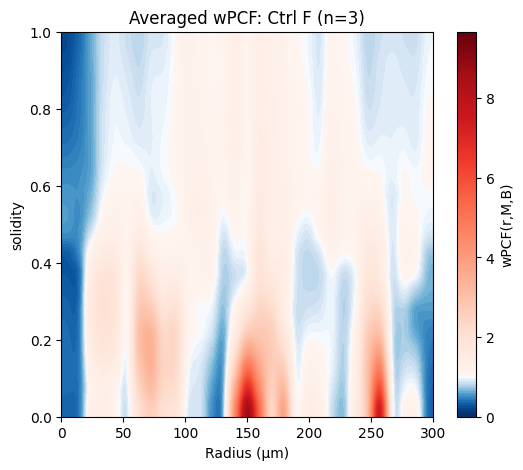

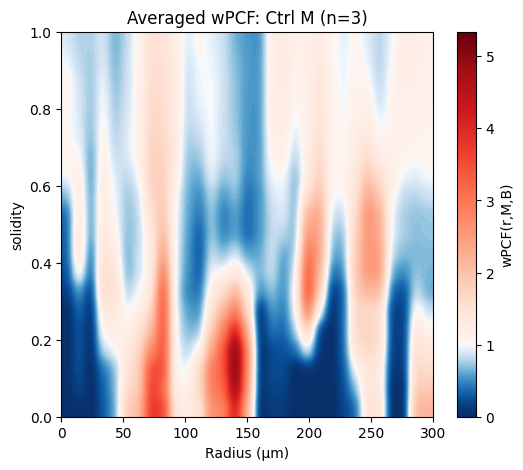

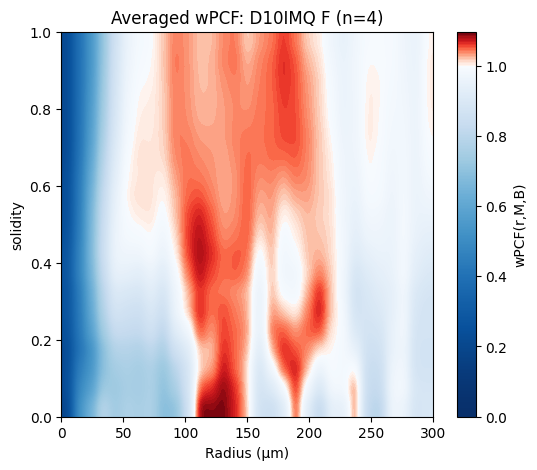

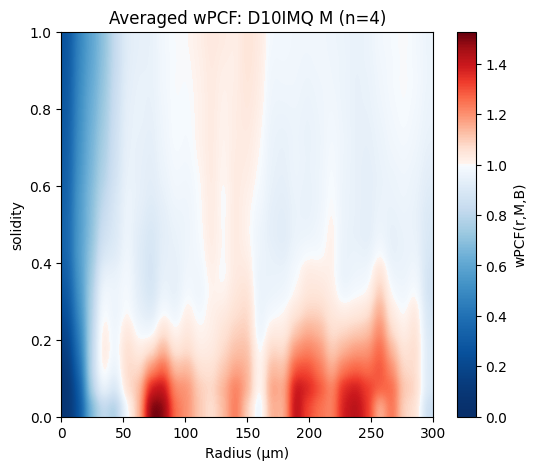

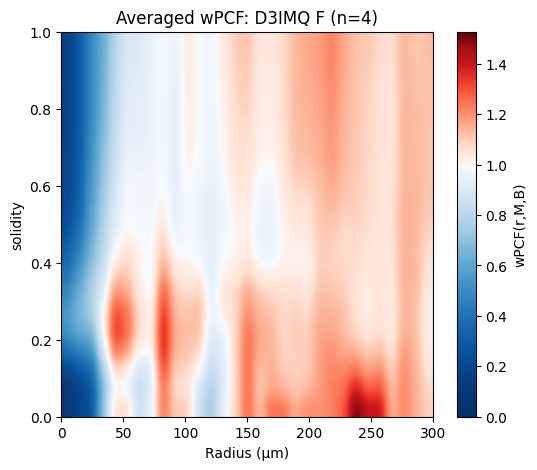

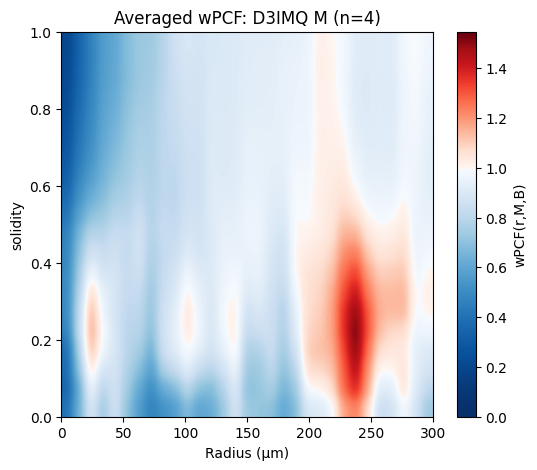

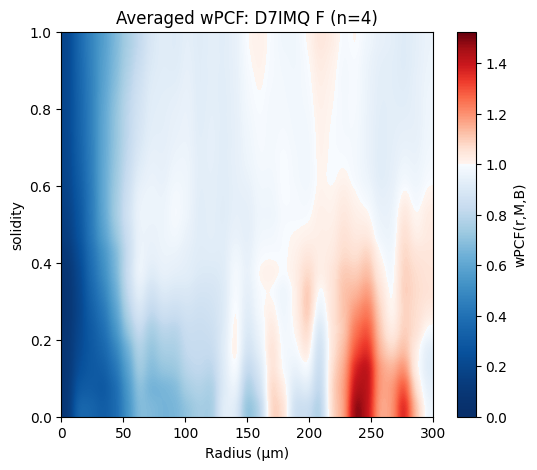

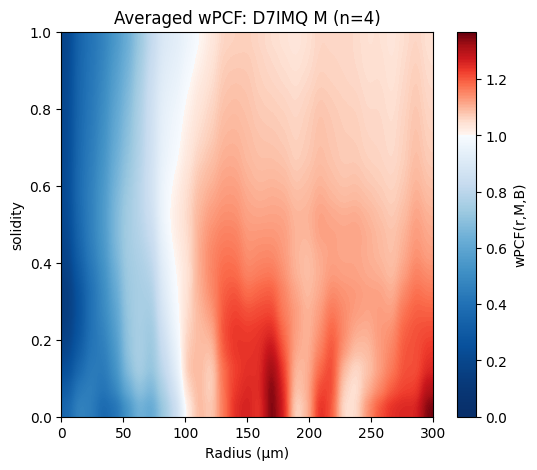

In [41]:
import numpy as np
import re
import matplotlib.pyplot as plt

"""GLOBAL_AREA_MIN = 0     
GLOBAL_AREA_MAX = 300 
GLOBAL_AREA_STEP = 25   """ #only use if trying to get area to work

grouped_wpcfs = {}
shared_radii = None

for name, domain in sorted(rep_domains.items()):
    
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
        
    group_key = match.group(1) 
    
    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'dermal_fibroblast')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB, 
        mark_pop_B=morph_prop, 
        max_R=300, 
        annulus_step=10, 
        annulus_width=15,
        # mark_min_pop_B=GLOBAL_AREA_MIN,   
        # mark_max_pop_B=GLOBAL_AREA_MAX,   
        # mark_step_pop_B=GLOBAL_AREA_STEP  
    )       
    
    
    # 2. Keep the longest radii array for the final visualization
    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

print("-" * 40)

# 3. Average the arrays with NaN Padding
averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    
    # Find the maximum rows and columns for this group
    max_rows = max([arr.shape[0] for arr in wpcf_list])
    max_cols = max([arr.shape[1] for arr in wpcf_list])
    
    padded_list = []
    
    for arr in wpcf_list:
        # Calculate how much padding is needed for rows and cols
        pad_rows = max_rows - arr.shape[0]
        pad_cols = max_cols - arr.shape[1]
        
        # Pad the bottom and right edges with NaNs
        padded_arr = np.pad(
            arr, 
            ((0, pad_rows), (0, pad_cols)), 
            mode='constant', 
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    # Now all arrays in the list are the exact same shape, so this will work:
    avg_wpcf = np.nanmean(padded_list, axis=0)
    averaged_wpcfs[group_key] = avg_wpcf
    
    
    fig, ax = ms.visualise.visualise_wpcf(
        shared_radii, 
        avg_wpcf, 
        figure_kwargs={'figsize': (6, 5)}
    )


    ax.set_title(f"Averaged wPCF: {group_key.replace("_", " ")} (n={len(wpcf_list)})")
    ax.set_ylabel(f"{morph_prop.replace("_", " ")}")
    ax.set_xlabel("Radius (µm)")
    
    plt.show()

----------------------------------------


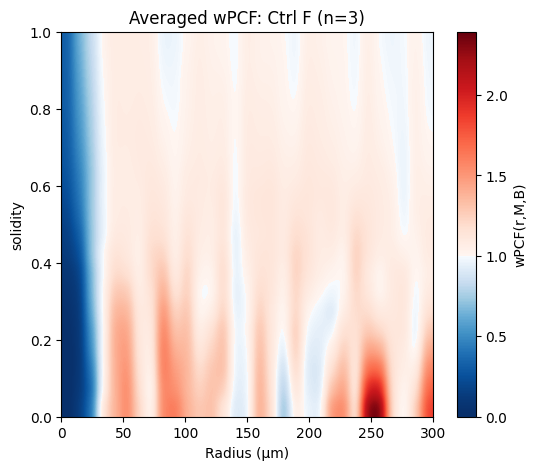

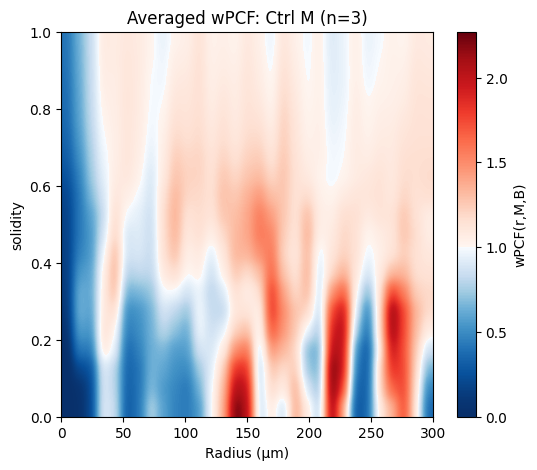

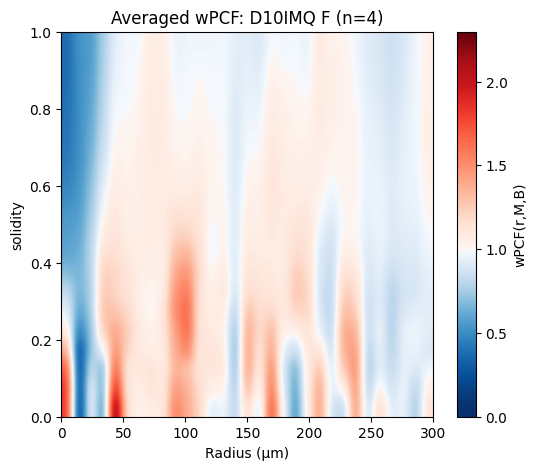

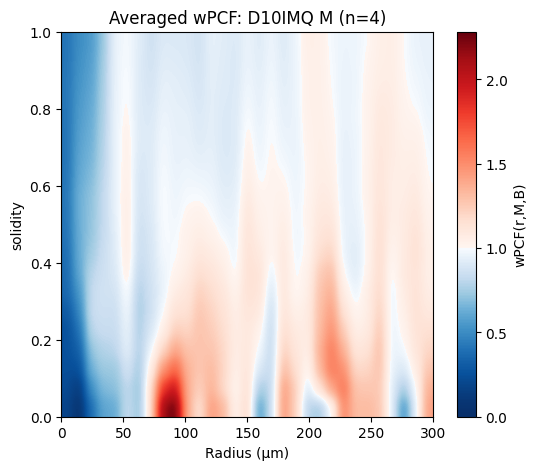

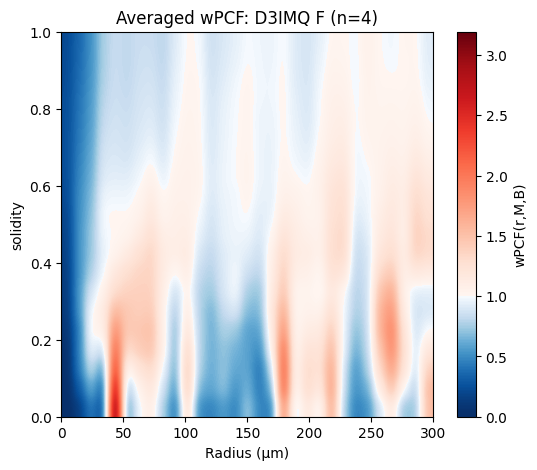

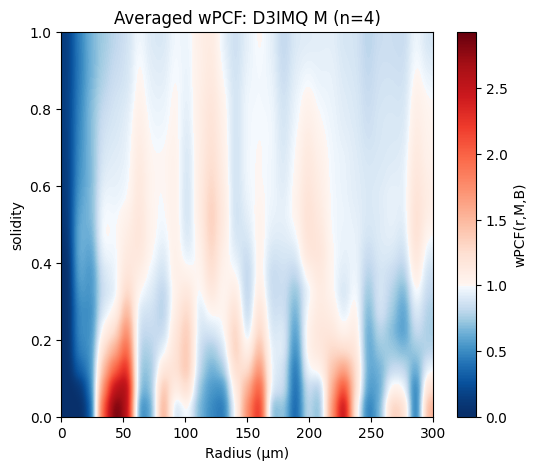

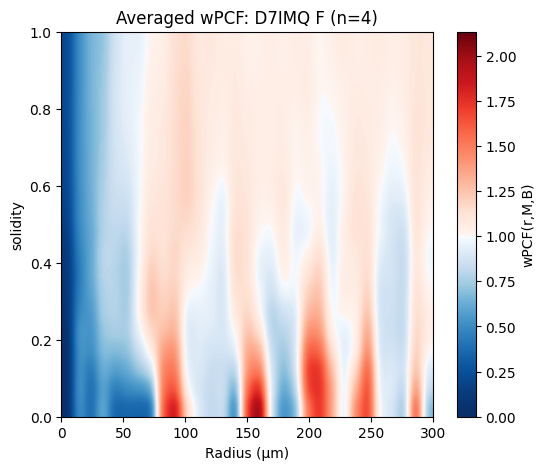

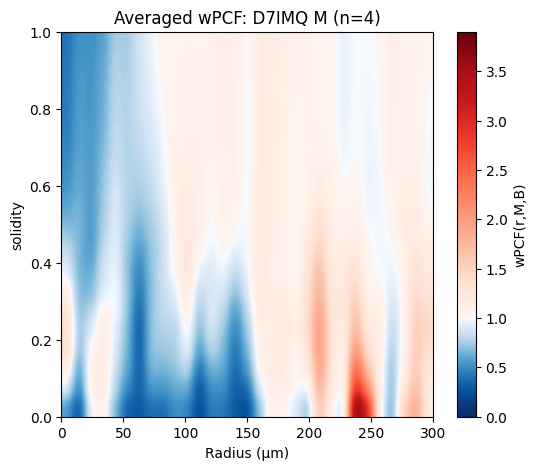

In [42]:
import numpy as np
import re
import matplotlib.pyplot as plt

"""GLOBAL_AREA_MIN = 0     
GLOBAL_AREA_MAX = 300 
GLOBAL_AREA_STEP = 25   """ #only use if trying to get area to work

grouped_wpcfs = {}
shared_radii = None

for name, domain in sorted(rep_domains.items()):
    
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
        
    group_key = match.group(1) 
    
    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'dermal_fibroblast')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB, 
        mark_pop_B=morph_prop, 
        max_R=300, 
        annulus_step=10, 
        annulus_width=15,
        # mark_min_pop_B=GLOBAL_AREA_MIN,   
        # mark_max_pop_B=GLOBAL_AREA_MAX,   
        # mark_step_pop_B=GLOBAL_AREA_STEP  
    )       
    
    
    # 2. Keep the longest radii array for the final visualization
    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

print("-" * 40)

# 3. Average the arrays with NaN Padding
averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    
    # Find the maximum rows and columns for this group
    max_rows = max([arr.shape[0] for arr in wpcf_list])
    max_cols = max([arr.shape[1] for arr in wpcf_list])
    
    padded_list = []
    
    for arr in wpcf_list:
        # Calculate how much padding is needed for rows and cols
        pad_rows = max_rows - arr.shape[0]
        pad_cols = max_cols - arr.shape[1]
        
        # Pad the bottom and right edges with NaNs
        padded_arr = np.pad(
            arr, 
            ((0, pad_rows), (0, pad_cols)), 
            mode='constant', 
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    # Now all arrays in the list are the exact same shape, so this will work:
    avg_wpcf = np.nanmean(padded_list, axis=0)
    averaged_wpcfs[group_key] = avg_wpcf
    
    
    fig, ax = ms.visualise.visualise_wpcf(
        shared_radii, 
        avg_wpcf, 
        figure_kwargs={'figsize': (6, 5)}
    )


    ax.set_title(f"Averaged wPCF: {group_key.replace("_", " ")} (n={len(wpcf_list)})")
    ax.set_ylabel(f"{morph_prop.replace("_", " ")}")
    ax.set_xlabel("Radius (µm)")
    
    plt.show()

----------------------------------------


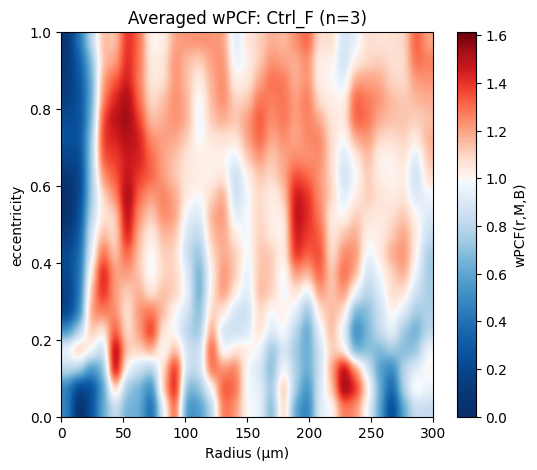

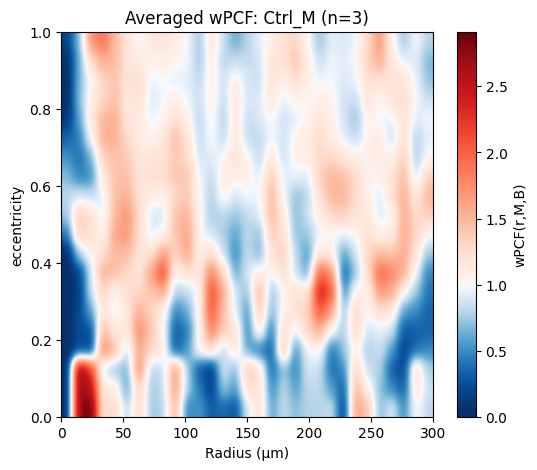

In [28]:
import numpy as np
import re
import matplotlib.pyplot as plt

"""GLOBAL_AREA_MIN = 0     
GLOBAL_AREA_MAX = 300 
GLOBAL_AREA_STEP = 25   """ #only use if trying to get area to work

grouped_wpcfs = {}
shared_radii = None

for name, domain in sorted(rep_domains.items()):
    
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
        
    group_key = match.group(1) 
    if group_key not in ['Ctrl_F', 'Ctrl_M']:
        continue
    
    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'myeloid')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB, 
        mark_pop_B=morph_prop, 
        max_R=300, 
        annulus_step=10, 
        annulus_width=15,
        # mark_min_pop_B=GLOBAL_AREA_MIN,   
        # mark_max_pop_B=GLOBAL_AREA_MAX,   
        # mark_step_pop_B=GLOBAL_AREA_STEP  
    )       
    
    
    # 2. Keep the longest radii array for the final visualization
    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

print("-" * 40)

# 3. Average the arrays with NaN Padding
averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    
    # Find the maximum rows and columns for this group
    max_rows = max([arr.shape[0] for arr in wpcf_list])
    max_cols = max([arr.shape[1] for arr in wpcf_list])
    
    padded_list = []
    
    for arr in wpcf_list:
        # Calculate how much padding is needed for rows and cols
        pad_rows = max_rows - arr.shape[0]
        pad_cols = max_cols - arr.shape[1]
        
        # Pad the bottom and right edges with NaNs
        padded_arr = np.pad(
            arr, 
            ((0, pad_rows), (0, pad_cols)), 
            mode='constant', 
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    # Now all arrays in the list are the exact same shape, so this will work:
    avg_wpcf = np.nanmean(padded_list, axis=0)
    averaged_wpcfs[group_key] = avg_wpcf
    
    
    fig, ax = ms.visualise.visualise_wpcf(
        shared_radii, 
        avg_wpcf, 
        figure_kwargs={'figsize': (6, 5)}
    )


    ax.set_title(f"Averaged wPCF: {group_key} (n={len(wpcf_list)})")
    ax.set_ylabel(f"{morph_prop.replace("_", " ")}")
    ax.set_xlabel("Radius (µm)")
    
    plt.show()